In [2]:
import pandas as pd
import numpy as np
import sidetable
pd.set_option('display.max_columns', None)
from collections import Counter
import re
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from plotnine import *
import math
from itertools import product
%matplotlib inline
import bibtexparser
# import biblib.bib
from thefuzz import process

In [3]:
# !pip3 install bibtexparser thefuzz

In [4]:
def fuzzy_match_titles(df, column_name, titles):
    title, score,num = process.extractOne(titles, df[column_name])
    return title
def remove_curly_braces(text):
    return text.replace('{', '').replace('}', '')

In [5]:
import bibtexparser
from bibtexparser.bwriter import BibTexWriter
from bibtexparser.bibdatabase import BibDatabase

# Function to read and parse a .bib file
def read_bibtex_file(file_path):
    with open(file_path, 'r') as bib_file:
        bib_database = bibtexparser.load(bib_file)
    return bib_database


In [6]:
# add bib column to df
file_path = 'covidence_yes.bib'  # Replace with your .bib file path
output_path = 'modified_bib.bib'
bib_database = read_bibtex_file(file_path)

In [7]:
bib_db_m = BibDatabase()
# ls_entries = ['ID','author', 'title', 'year', 'pages', 'publisher', 'journal', 'organization', 'booktitle']
for entry in bib_database.entries:
    entry_m = {key: entry[key] for key in entry.keys() & {'ENTRYTYPE','ID','author', 'title', 'year', 'pages', 'publisher', 'journal', 'organization', 'booktitle'}}
    bib_db_m.entries.append(entry_m)

with open(output_path, 'w', encoding='utf-8') as bibfile:
    writer = BibTexWriter()
    bibfile.write(writer.write(bib_db_m))


In [8]:
for entry in bib_db_m.entries:
    print(entry)

{'year': '2020', 'ID': 'musthafa_towards_2020', 'title': 'Towards the {Development} of a {User}-{Centred} {Health} {Management} {Application} for {Elderly}', 'booktitle': '2020 2nd {International} {Conference} on {Advancements} in {Computing} ({ICAC})', 'ENTRYTYPE': 'inproceedings', 'pages': '13--18', 'author': 'Musthafa, Fathima Naja and Mustafa, Mumtaz Begum and Tajudeen, Farzana Parveen and Ramasamy, Thamil Selvee and Sinniah, Ajantha'}
{'year': '2017', 'ID': 'sorgalla_improving_2017', 'title': 'Improving {Representativeness} in {Participatory} {Design} {Processes} with {Elderly}', 'booktitle': 'Proceedings of the 2017 {CHI} {Conference} {Extended} {Abstracts} on {Human} {Factors} in {Computing} {Systems}', 'ENTRYTYPE': 'inproceedings', 'publisher': 'ACM', 'pages': '2107--2114', 'author': 'Sorgalla, Jonas and Schabsky, Peter and Sachweh, Sabine and Grates, Miriam and Heite, Elisabeth'}
{'year': '2021', 'ID': 'gollasch_age-related_2021', 'title': 'Age-{Related} {Differences} in {Pref

In [17]:
df_ppls = pd.read_csv('SLR_paperlist.csv')

In [18]:
df_ppls = df_ppls.head(69)

In [19]:
df_ppls['Title_Duplicate'] = df_ppls['2. Paper Title']
df_ppls.set_index('2. Paper Title', inplace=True)

In [20]:

matched_titles = []
for entry in bib_database.entries:
    titles = remove_curly_braces(entry.get('title', 'N/A'))
#     print(titles)
    match = fuzzy_match_titles(df_ppls, 'Title_Duplicate', titles)
#     print(match)
    df_ppls.at[match, 'bib'] = entry.get('ID', 'N/A')

In [21]:

df_ppls['Numeric_Part'] = df_ppls['1. Paper ID'].str.extract('(\d+)').astype(int)

# Sort DataFrame based on the numeric part
df_sorted = df_ppls.sort_values('Numeric_Part')

# Drop the numeric part column if not needed
df_sorted.drop('Numeric_Part', axis=1, inplace=True)

df_sorted['Modified_bib'] = df_sorted.apply(lambda row: f"\item \\textbf{{{row['1. Paper ID']}}} \\bibentry{{{row['bib']}}}", axis=1)


In [22]:
# print the bibentry in the format fot SLR
values_without_quotes = df_sorted['Modified_bib'].values.tolist()

# Print each value without quotes
# for value in values_without_quotes:
#     print(value)


In [23]:
df_ppls

,1. Paper ID,3. Paper Author(s),4. Published Year,5. Venue (Name of the Journal/Conference published),Item Type,6. The number of citations of the study(Google scholar),7. Quality Score,Title_Duplicate,bib,Numeric_Part
2. Paper Title,,,,,,,,,,
"“Maybe It Becomes a Buddy, But Do Not Call It a Robot” – Seamless Cooperation between Companion Robotics and Smart Homes",S19,"Huijnen, Claire; Badii, Atta; Van Den Heuvel, ...",2011.0,Ambient Intelligence,bookSection,58,4.0,"“Maybe It Becomes a Buddy, But Do Not Call It ...",beltran_smart_2022,19
A design methodology for matching smart health requirements,S27,"Bellandi, V.; Ceravolo, P.; Cristiano, A.; Dam...",2021.0,Concurrency and Computation: Practice and Expe...,journalArticle,16,3.0,A design methodology for matching smart health...,scandurra_user_2008,27
A Model-Driven Engineering Approach for the Well-Being of Ageing People,S16,"Koshima, A.A.; Englebert, V.; Amani, M.; Debie...",2016.0,Advances in Conceptual Modeling. ER 2016 Works...,conferencePaper,2,3.0,A Model-Driven Engineering Approach for the We...,koshima_model-driven_2016,16
A Participatory Design Methodology to Elicit Aging- in-Place Stakeholder Concerns with Ambient Assistive Living (AAL) Devices During COVID-19,S14,"Robinson, Katherine-Marie; Devkota, Rachana; M...",2022.0,2022 IEEE 30th International Requirements Engi...,conferencePaper,1,5.0,A Participatory Design Methodology to Elicit A...,robinson_participatory_2022,14
A Usability Evaluation Instrument for Pain Management Mobile Applications: An Elderly’s Perspective,S34,"Umm e Mariya Shah, Thiam Kian Chiew; Mehmood, ...",2022.0,International Journal of Human–Computer Intera...,journalArticle,0,5.0,A Usability Evaluation Instrument for Pain Man...,umm_e_mariya_shah_usability_2022,34
...,...,...,...,...,...,...,...,...,...,...
User-Innovated eHealth Solutions for Service Delivery to Older Persons With Hearing Impairment,S66,"Nielsen, Annette Cleveland; Rotger, -Griful Se...",2018.0,American Journal of Audiology,journalArticle,23,4.0,User-Innovated eHealth Solutions for Service D...,nielsen_user-innovated_2018,66
"Using Work System Design, User Stories and Emotional Goal Modeling for an mHealth System",S7,"Abdullah, Nik Nailah Binti; Grundy, John; McIn...",2020.0,2020 IEEE First International Workshop on Requ...,conferencePaper,9,5.0,"Using Work System Design, User Stories and Emo...",abdullah_using_2020,7
Virtual communities for elderly healthcare: user-based requirements elicitation,S36,"van 't Klooster, J.-W.; van Beijnum, B.-J.; Pa...",2011.0,International Journal of Networking and Virtua...,journalArticle,9,4.0,Virtual communities for elderly healthcare: us...,van_t_klooster_virtual_2011,36


In [24]:
df_ppls[df_ppls['bib'].isna()]

,1. Paper ID,3. Paper Author(s),4. Published Year,5. Venue (Name of the Journal/Conference published),Item Type,6. The number of citations of the study(Google scholar),7. Quality Score,Title_Duplicate,bib,Numeric_Part
2. Paper Title,,,,,,,,,,


In [25]:
df_ppls['4. Published Year'] = df_ppls['4. Published Year'].astype(str)

In [26]:
uni_yr = sorted(df_ppls['4. Published Year'].unique().tolist())

In [27]:
print(uni_yr)

['2001.0', '2007.0', '2008.0', '2011.0', '2012.0', '2013.0', '2014.0', '2015.0', '2016.0', '2017.0', '2018.0', '2019.0', '2020.0', '2021.0', '2022.0']


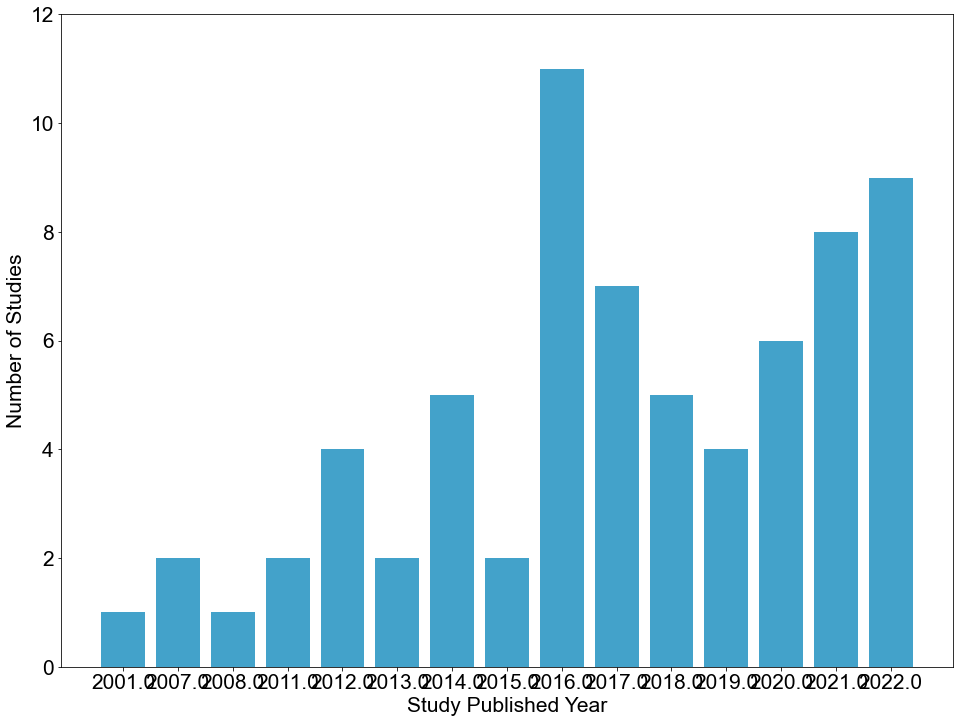

In [28]:
start_year = df_ppls['4. Published Year'].min()
end_year = df_ppls['4. Published Year'].max()

# Count the number of papers published in each year
year_counts = df_ppls['4. Published Year'].value_counts().sort_index()


# Filter out years with count 0
x_values = [year for year, count in year_counts.items() if count > 0]
y_values = [count for count in year_counts.values if count > 0]




plt.figure(figsize=(16, 12))
plt.rcParams['font.size'] = 21
plt.rcParams['font.family'] = 'Arial'
# Create a bar chart
plt.bar(x_values, y_values, color='#43a2ca')
plt.xticks(np.arange(len(uni_yr)),uni_yr)
plt.ylim(0,12)
# Add labels and title
plt.xlabel('Study Published Year')
plt.ylabel('Number of Studies')
# plt.title('Study Distribution by Year')


# Set the X-axis ticks and labels to show all years
# plt.xticks(ticks=x_values, labels=[str(year) for year in x_values])
# Set the X-axis limits to include 2000 and 2018
# plt.xlim(2000, 2024)
# Display the plot
plt.savefig('Study Distribution by Year.pdf')
plt.show()


In [29]:
df_ppls['6. The number of citations of the study(Google scholar)'] = df_ppls['6. The number of citations of the study(Google scholar)'].astype(int)
bins = [-1,0, 25, 50, 75, 100, 150, 200,250, 300,350]

# Add a new column with bucket ranges
df_ppls['citation'] = pd.cut(df_ppls['6. The number of citations of the study(Google scholar)'], bins=bins, labels=['0','0-25', '25-50', '50-75', '75-100','100-150','150-200','200-250','250-300','>300'])

# uni_yr = sorted(df_ppls['citation'].unique().tolist())
# print(uni_yr)

In [30]:
df_ppls

,1. Paper ID,3. Paper Author(s),4. Published Year,5. Venue (Name of the Journal/Conference published),Item Type,6. The number of citations of the study(Google scholar),7. Quality Score,Title_Duplicate,bib,Numeric_Part,citation
2. Paper Title,,,,,,,,,,,
"“Maybe It Becomes a Buddy, But Do Not Call It a Robot” – Seamless Cooperation between Companion Robotics and Smart Homes",S19,"Huijnen, Claire; Badii, Atta; Van Den Heuvel, ...",2011.0,Ambient Intelligence,bookSection,58,4.0,"“Maybe It Becomes a Buddy, But Do Not Call It ...",beltran_smart_2022,19,50-75
A design methodology for matching smart health requirements,S27,"Bellandi, V.; Ceravolo, P.; Cristiano, A.; Dam...",2021.0,Concurrency and Computation: Practice and Expe...,journalArticle,16,3.0,A design methodology for matching smart health...,scandurra_user_2008,27,0-25
A Model-Driven Engineering Approach for the Well-Being of Ageing People,S16,"Koshima, A.A.; Englebert, V.; Amani, M.; Debie...",2016.0,Advances in Conceptual Modeling. ER 2016 Works...,conferencePaper,2,3.0,A Model-Driven Engineering Approach for the We...,koshima_model-driven_2016,16,0-25
A Participatory Design Methodology to Elicit Aging- in-Place Stakeholder Concerns with Ambient Assistive Living (AAL) Devices During COVID-19,S14,"Robinson, Katherine-Marie; Devkota, Rachana; M...",2022.0,2022 IEEE 30th International Requirements Engi...,conferencePaper,1,5.0,A Participatory Design Methodology to Elicit A...,robinson_participatory_2022,14,0-25
A Usability Evaluation Instrument for Pain Management Mobile Applications: An Elderly’s Perspective,S34,"Umm e Mariya Shah, Thiam Kian Chiew; Mehmood, ...",2022.0,International Journal of Human–Computer Intera...,journalArticle,0,5.0,A Usability Evaluation Instrument for Pain Man...,umm_e_mariya_shah_usability_2022,34,0
...,...,...,...,...,...,...,...,...,...,...,...
User-Innovated eHealth Solutions for Service Delivery to Older Persons With Hearing Impairment,S66,"Nielsen, Annette Cleveland; Rotger, -Griful Se...",2018.0,American Journal of Audiology,journalArticle,23,4.0,User-Innovated eHealth Solutions for Service D...,nielsen_user-innovated_2018,66,0-25
"Using Work System Design, User Stories and Emotional Goal Modeling for an mHealth System",S7,"Abdullah, Nik Nailah Binti; Grundy, John; McIn...",2020.0,2020 IEEE First International Workshop on Requ...,conferencePaper,9,5.0,"Using Work System Design, User Stories and Emo...",abdullah_using_2020,7,0-25
Virtual communities for elderly healthcare: user-based requirements elicitation,S36,"van 't Klooster, J.-W.; van Beijnum, B.-J.; Pa...",2011.0,International Journal of Networking and Virtua...,journalArticle,9,4.0,Virtual communities for elderly healthcare: us...,van_t_klooster_virtual_2011,36,0-25


In [31]:
result = bar_Chart_cat(df_ppls,'1. Paper ID','6. The number of citations of the study(Google scholar)')
result = result.sort_values(by='Occurrences', ascending=False)

NameError: name 'bar_Chart_cat' is not defined

In [32]:
result1 = bar_Chart_cat(df_ppls,'1. Paper ID','citation')
result1 = result1.sort_values(by='Occurrences', ascending=False)

NameError: name 'bar_Chart_cat' is not defined

In [33]:
result1.to_clipboard(index=False, sep='\t')

NameError: name 'result1' is not defined

In [34]:
result1

NameError: name 'result1' is not defined

In [35]:
result.to_clipboard(index=False, sep='\t')

NameError: name 'result' is not defined

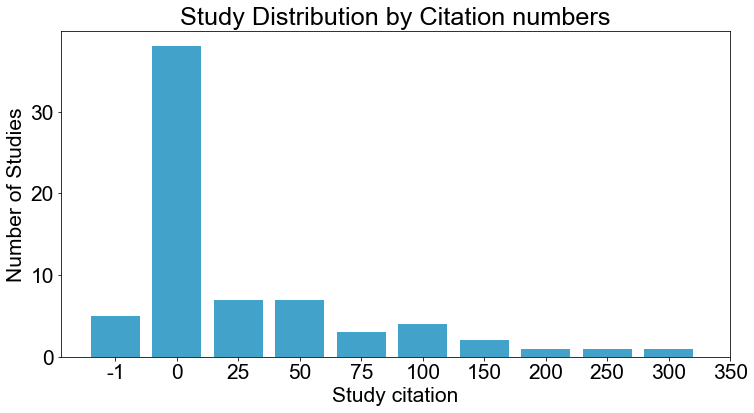

In [36]:

start_year = df_ppls['citation'].min()
end_year = df_ppls['citation'].max()

# Count the number of papers published in each year
year_counts = df_ppls['citation'].value_counts().sort_index()


# Filter out years with count 0
x_values = [year for year, count in year_counts.items() if count > 0]
y_values = [count for count in year_counts.values if count > 0]




plt.figure(figsize=(12, 6))
plt.rcParams['font.size'] = 21
plt.rcParams['font.family'] = 'Arial'
# Create a bar chart
plt.bar(x_values, y_values, color='#43a2ca')
plt.xticks(np.arange(len(bins)),bins)
# plt.ylim(0,8)
# Add labels and title
plt.xlabel('Study citation')
plt.ylabel('Number of Studies')
plt.title('Study Distribution by Citation numbers')


# Set the X-axis ticks and labels to show all years
# plt.xticks(ticks=x_values, labels=[str(year) for year in x_values])
# Set the X-axis limits to include 2000 and 2018
# plt.xlim(2000, 2024)
# Display the plot
plt.savefig('Study Distribution by Citation numbers.pdf')
plt.show()


In [31]:
df_ppls['Item Type'].unique()

array(['bookSection', 'journalArticle', 'conferencePaper'], dtype=object)

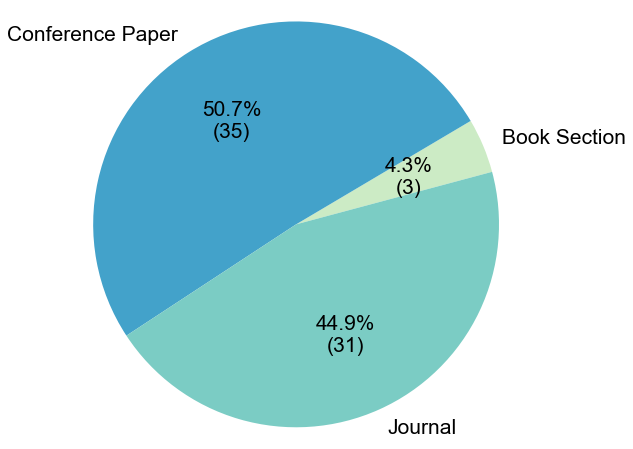

In [163]:

category_mapping = {'journalArticle': 'Journal','bookSection': 'Book Section', 'conferencePaper': 'Conference Paper'}

# Replace category names in the 'Category' column
df_ppls['Item Type'] = df_ppls['Item Type'].replace(category_mapping)
category_counts = df_ppls['Item Type'].value_counts().sort_index()
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format
# Generate pie chart

plt.figure(figsize=(8, 8))
colors = [ '#ccebc5','#43a2ca','#7bccc4']
plt.rcParams['font.size'] = 21
plt.rcParams['font.family'] = 'Arial'
# fig, ax = plt.subplots()
plt.pie(category_counts, colors=colors, labels=category_counts.index,startangle=15, autopct=autopct_format(category_counts))
# plt.pie(df['LoanStatus'].value_counts().values, labels=df['LoanStatus'].value_counts().index, autopct=fmt)
# ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)

# ax.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# plt.title('Pie Chart of Category Counts')
# plt.legend(prop={'size': 12, 'family': 'Comic Sans MS'})
# plt.update_layout(width=700, height=700, showlegend=False)

plt.savefig('Study Distribution by Publication Type.pdf')
plt.show()


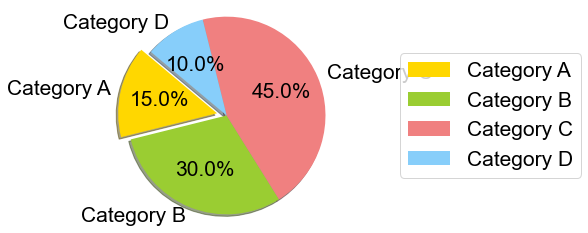

In [164]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Category A', 'Category B', 'Category C', 'Category D']
sizes = [15, 30, 45, 10]
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0.1, 0, 0, 0)  # explode 1st slice

# Create the pie chart
fig, ax = plt.subplots()
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)

# Add the legend outside the pie chart
ax.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5))

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')  
plt.rcParams['font.size'] = 21
plt.rcParams['font.family'] = 'Arial'
plt.show()


In [165]:
# labels = df_ppls['4. Published Year'].astype(int).tolist()

# # Create a bar chart
# create_bar_chart(labels, 'Study Published Year', 'Number of Studies')


In [32]:
df_raw = pd.read_csv('DataExtractionSLR_yq.csv')

In [33]:
# df_raw.columns = df_raw.iloc[0]

In [34]:
df_raw

,Who is answering this form?,Paper ID,First Author's affiliation,The number of citations of the study,9.what are the key aim(s) of the study?(eg.from abstract or introduction),"10. If there are any participants, how many participants are involved? How many of them are elderly people?",Unnamed: 6,10_add_elderly,10_add_caregivers,Unnamed: 9,10_add_f>m,"11. If any elderly participants in this study, what is their age range?",11_fuzzyrange,11_meanAge,12.Were AI/ML solutions involved in the requirements capture/the solution proposed?,"13.If so, what AI/ML solutions were used, what for and why",13_AI _solutions,13_AI_usage,14.What method(s) of data capture and usage are used?,14_data_collection_tool,14_data_capture,data usage,15. What are the health aspect of elderly people studied?,"16. What is the health aspect in this study?(eg.fall, hearing-aid, cancer, etc.)",17. What are their key outcome?,18.What are the different human aspects that were considered in the RE (if any)?,24.Is the data available from the study?,19.What RE techniques did they use?,20.How are the requirements modelled,21.How were the requirements validated in the study?,22.which parts of process of system building are the requirements used (if described)?,"23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?",25.What RE tools were used in the study?,28. How are the results of the study evaluated?,26. Is the study conducted in academia or industry?,27. What is the nature/type of the study?,Is the end user of this study's outcome only elderly?(eg. Does it involve aged care givers?),Is this study's target group for elderly group only?(eg. is it also for disabled group?),29.What are the main findings of the study,29. findings,30. What are the benefits of the RE approaches reported in the study?,30.benefits,"31.What are the limitations, key challenges or problems relating to RE-related tasks that were reported (if any)?",31.limitations,32.What recommendations for improving/extending the RE approaches were reported in the study?,32.recommendations,33.What were the key research gaps/future work identified in the study?,Unnamed: 47,33.future work,33.future work_gen,"34.Any other observations or comments of interest from the study, or summary the paper",Should this paper be included?,If no or doubtful give the reason,The quality score of this paper (Yuqing will do this later)
0,yq,S1,NaN,NaN,The key aim of the study is to investigate fac...,31,NaN,31,0,NaN,unclear,"not clear, but in thailand >=60 normally consi...",>=60,unclear,No,no,NaN,non,survey of questions based on the constructs de...,mapp,mapp data,e-Health services,"In general ageing challenge(eg. smart home, nu...","ageing (in general), living/home assistance",mhealth app,"Emotions, Comfort with technology, Education, ...",no data included,Reusing existing requirements,Structured English,Non,unclear,no evaluation,Text(Word/Docs)/Table(Excel/Sheets),"Statistical Significance, pearson correlation,...",academia,Requirements Gathering Exercise (RE is the foc...,yes,yes,"the study found that Perceived Value, Effort E...",Technological Innovation and Adoption,to ensure that the eventual e-Health services...,"Understanding User Needs/Barriers, improving/S...",it mentions a limitation from a research pers...,Participant Representation and Bias,The content suggests that future research shou...,RE Method improvements,the results of the research is still useful fo...,NaN,better e-Health mApp based on results,Further development,NaN,NaN,NaN,NaN
1,yq,S10,NaN,NaN,1.Requirement engineers face challenges in ass...,10,healthcare providers,10,0,10,unclear,65,>=65,unclear,No,non,NaN,non,interviews and group discussion data,NaN,unclear,unclear,"In general ageing challenge(eg. smart home, nu...",ageing (in general),RE framework,"Personality, Cognitive and Educational level, ...",no,"Interviews, Workshops, Observations, Rapid Pro...",Structured English,"Requirements Review, Protot

### split raw data into 2 dataframe
df_raw_yq: yq's response

df_raw_val: john and anu's validation 

df_raw: all non_duplicate responses, 63 in total

In [35]:
df_raw_yq=df_raw.loc[df_raw['Who is answering this form?'] == "yq"]
df_raw_val=df_raw.loc[df_raw['Who is answering this form?'] != "yq"]


In [36]:
# S65 = df_raw_val.loc[df_raw_val["Paper ID"]=="S65"]

In [37]:
# df_raw = pd.concat([df_raw_yq, S65])

In [38]:
# df_raw

In [39]:
df_raw = df_raw_yq

In [40]:
df_raw.columns

Index(['Who is answering this form?', 'Paper ID', 'First Author's affiliation',
       'The number of citations of the study',
       '9.what are the key aim(s) of the study?(eg.from abstract or introduction)',
       '10. If there are any participants, how many participants are involved? How many of them are elderly people?',
       'Unnamed: 6', '10_add_elderly', '10_add_caregivers', 'Unnamed: 9',
       '10_add_f>m',
       '11. If any elderly participants in this study, what is their age range?',
       '11_fuzzyrange', '11_meanAge',
       '12.Were AI/ML solutions involved in the requirements capture/the solution proposed?',
       '13.If so, what AI/ML solutions were used, what for and why',
       '13_AI _solutions', '13_AI_usage',
       '14.What method(s) of data capture and usage are used?',
       '14_data_collection_tool', '14_data_capture', 'data usage',
       '15. What are the health aspect of elderly people studied?',
       '16. What is the health aspect in this study?

In [41]:
df_raw['23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?'] = df_raw['23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?'].astype(str).map(str.lower)

<ipython-input-41-41bbcdb87a29>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [42]:
df_raw['23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?'] = df_raw['23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?'].astype(str).map(str.lower)

<ipython-input-42-41bbcdb87a29>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [43]:
# df_raw['29.What are the main findings of the study '].replace("\n", "").tolist()
# df_raw['29.What are the main findings of the study '].apply(lambda x: x.replace("\n", "")).tolist()


In [44]:
df_RQ1 = df_raw[['Paper ID',
       '9.what are the key aim(s) of the study?(eg.from abstract or introduction)',
       '10. If there are any participants, how many participants are involved? How many of them are elderly people?',
                 'Unnamed: 6','10_add_elderly', '10_add_caregivers', '10_add_f>m',
       '11. If any elderly participants in this study, what is their age range?',
       '11_fuzzyrange', '11_meanAge',
                 '12.Were AI/ML solutions involved in the requirements capture/the solution proposed?',
       '13.If so, what AI/ML solutions were used, what for and why',
       '13_AI _solutions','13_AI_usage',
                 '14.What method(s) of data capture and usage are used?',
        '14_data_collection_tool','14_data_capture','data usage',
       '15. What are the health aspect of elderly people studied?',
       '16. What is the health aspect in this study?(eg.fall, hearing-aid, cancer, etc.)',
       '17. What are their key outcome?',
       '18.What are the different human aspects that were considered in the RE (if any)?',
      '24.Is the data available from the study? ']]

In [45]:
df_RQ1.rename(columns={'Paper ID':'Paper ID',
    '9.what are the key aim(s) of the study?(eg.from abstract or introduction)': "9",
                       '10. If there are any participants, how many participants are involved? How many of them are elderly people?':"10",
                       'Unnamed: 6':'participants','10_add_elderly':'10_elderly', '10_add_caregivers':'10_caregivers', '10_add_f>m':'10_f>m',
       '11. If any elderly participants in this study, what is their age range?':"11",
       '11_fuzzyrange':'11_fuzzyrange','11_meanAge': '11_meanAge',
                       '12.Were AI/ML solutions involved in the requirements capture/the solution proposed?':"12",
       '13.If so, what AI/ML solutions were used, what for and why':"13",
       '13_AI _solutions':'13_AI _solutions',
                       '13_AI_usage':'13_AI_usage',
                       '14.What method(s) of data capture and usage are used?':"14",
       '14_data_collection_tool':'14_data_collection_tool',
                       '14_data_capture':'14_data_capture',
                       'data usage':'14_data_usage',
                       '15. What are the health aspect of elderly people studied?':"15",
       '16. What is the health aspect in this study?(eg.fall, hearing-aid, cancer, etc.)':"16",
       '17. What are their key outcome?':"17",
       '18.What are the different human aspects that were considered in the RE (if any)?':"18",
      '24.Is the data available from the study? ':"24"},inplace=True)

<ipython-input-45-5a38dfad59b5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [46]:
df_RQ2 = df_raw[['Paper ID','19.What RE techniques did they use?',
       '20.How are the requirements modelled',
       '21.How were the requirements validated in the study?',
       '22.which parts of process of system building are the requirements used (if described)?',
       '23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?',
       '25.What RE tools were used in the study?',
       '28. How are the results of the study evaluated?']]

In [47]:
df_RQ2.rename(columns={'Paper ID':'Paper ID','19.What RE techniques did they use?':'19',
       '20.How are the requirements modelled':'20',
       '21.How were the requirements validated in the study?':'21',
       '22.which parts of process of system building are the requirements used (if described)?':'22',
       '23. If study includes evaluation, were the requirements used to evaluate the solution design/implementation?':'23',
       '25.What RE tools were used in the study?':'25',
       '28. How are the results of the study evaluated?':'28'},inplace=True)

<ipython-input-47-3b0710c0f541>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [48]:
df_RQ3 = df_raw[['Paper ID','26. Is the study conducted in academia or industry?',
       '27. What is the nature/type of the study?',
       "Is the end user of this study's outcome only elderly?(eg. Does it involve aged care givers?)",
      "Is this study's target group for elderly group only?(eg. is it also for disabled group?)"]]

In [49]:
df_RQ3.rename(columns={'Paper ID':'Paper ID', 
       '26. Is the study conducted in academia or industry?':'26',
       '27. What is the nature/type of the study?':'27',
       "Is the end user of this study's outcome only elderly?(eg. Does it involve aged care givers?)":'end user elderly only?',
       "Is this study's target group for elderly group only?(eg. is it also for disabled group?)":'target group elderly only?'},inplace=True)

<ipython-input-49-8e72c707162f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [50]:
df_RQ3['end user elderly only?'] = df_RQ3['end user elderly only?'].str.upper()

<ipython-input-50-a0bfe0f1f3f5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [51]:
df_RQ4 = df_raw[['Paper ID','29.What are the main findings of the study ',
                 '29. findings',
       '30. What are the benefits of the RE approaches reported in the study?',
                 '30.benefits',
       '31.What are the limitations, key challenges or problems relating to RE-related tasks that were reported (if any)?',
                 '31.limitations',
       '32.What recommendations for improving/extending the RE approaches were reported in the study?',
                 '32.recommendations ',
       '33.What were the key research gaps/future work identified in the study?',
                 '33.future work', '33.future work_gen',
       '34.Any other observations or comments of interest from the study, or summary the paper']]

In [52]:
df_RQ4.rename(columns={'Paper ID':'Paper ID',
                       '29. findings':'29',
       '30.benefits':'30',
       '31.limitations':'31',
                       '32.recommendations ':'32',
                       '33.future work_gen':'33',
       '34.Any other observations or comments of interest from the study, or summary the paper':'34'},inplace=True)

<ipython-input-52-ade924323fed>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [53]:
df_RE4Domain = df_raw[['Paper ID',
                       '13_AI _solutions','13_AI_usage',
                       '15. What are the health aspect of elderly people studied?',
       '16. What is the health aspect in this study?(eg.fall, hearing-aid, cancer, etc.)',
                       '19.What RE techniques did they use?',
       '20.How are the requirements modelled'
       ]]

In [54]:
df_RE4Domain.rename(columns={'Paper ID':'Paper ID',
                              '13_AI _solutions':'13_AI _solutions',
                       '13_AI_usage':'13_AI_usage',
                             '15. What are the health aspect of elderly people studied?':"15",
                             '16. What is the health aspect in this study?(eg.fall, hearing-aid, cancer, etc.)':'16',
                               '19.What RE techniques did they use?':'19',
                               '20.How are the requirements modelled':'20'},inplace=True)

<ipython-input-54-418da08878fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [55]:
ls_rq4 = df_RQ4['29'].apply(lambda x: x.replace("\n", "")).tolist()
result_dict = dict(zip(df_RQ4['Paper ID'], ls_rq4))


In [56]:
# result_dict

In [57]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
import numpy as np

# Data
papers = result_dict

# Extract keywords from each benefit
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(list(papers.values()))

# Cluster the keywords
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X)

# Organize papers into clusters
clustered_papers = {}
for i, paper_id in enumerate(papers.keys()):
    cluster_id = clusters[i]
    if cluster_id not in clustered_papers:
        clustered_papers[cluster_id] = []
    clustered_papers[cluster_id].append(paper_id)

# Print clusters and papers in each cluster
for cluster_id, papers_in_cluster in clustered_papers.items():
    print(f"Cluster {cluster_id + 1}:")
    for paper_id in papers_in_cluster:
        print(f"Paper ID: {paper_id}")
    print()


Cluster 1:
Paper ID: S1
Paper ID: S10
Paper ID: S11
Paper ID: S12
Paper ID: S13
Paper ID: S16
Paper ID: S18
Paper ID: S24
Paper ID: S28
Paper ID: S30
Paper ID: S31
Paper ID: S32
Paper ID: S33
Paper ID: S34
Paper ID: S40
Paper ID: S44
Paper ID: S47
Paper ID: S48
Paper ID: S54

Cluster 3:
Paper ID: S14
Paper ID: S15
Paper ID: S17
Paper ID: S19
Paper ID: S61
Paper ID: S63

Cluster 2:
Paper ID: S2
Paper ID: S22
Paper ID: S23
Paper ID: S25
Paper ID: S26
Paper ID: S27
Paper ID: S42
Paper ID: S43
Paper ID: S45
Paper ID: S46
Paper ID: S49
Paper ID: S50
Paper ID: S53
Paper ID: S55
Paper ID: S56
Paper ID: S57
Paper ID: S58
Paper ID: S6
Paper ID: S60
Paper ID: S64
Paper ID: S7
Paper ID: S8
Paper ID: S65
Paper ID: S59

Cluster 5:
Paper ID: S20
Paper ID: S35
Paper ID: S36
Paper ID: S37
Paper ID: S38
Paper ID: S52
Paper ID: S62
Paper ID: S9
Paper ID: S39
Paper ID: S21
Paper ID: S29
Paper ID: S67
Paper ID: S51
Paper ID: S66

Cluster 7:
Paper ID: S3
Paper ID: S4
Paper ID: S41

Cluster 6:
Paper ID: S5


In [58]:
df_RQ4.columns

Index(['Paper ID', '29.What are the main findings of the study ', '29',
       '30. What are the benefits of the RE approaches reported in the study?',
       '30',
       '31.What are the limitations, key challenges or problems relating to RE-related tasks that were reported (if any)?',
       '31',
       '32.What recommendations for improving/extending the RE approaches were reported in the study?',
       '32',
       '33.What were the key research gaps/future work identified in the study?',
       '33.future work', '33', '34'],
      dtype='object')

In [59]:
df_RQ4

,Paper ID,29.What are the main findings of the study,29,30. What are the benefits of the RE approaches reported in the study?,30,"31.What are the limitations, key challenges or problems relating to RE-related tasks that were reported (if any)?",31,32.What recommendations for improving/extending the RE approaches were reported in the study?,32,33.What were the key research gaps/future work identified in the study?,33.future work,33,34
0,S1,"the study found that Perceived Value, Effort E...",Technological Innovation and Adoption,to ensure that the eventual e-Health services...,"Understanding User Needs/Barriers, improving/S...",it mentions a limitation from a research pers...,Participant Representation and Bias,The content suggests that future research shou...,RE Method improvements,the results of the research is still useful fo...,better e-Health mApp based on results,Further development,NaN
1,S10,"This research presents the SeniorDT approach, ...",Technological Innovation and Adoption,They improve the traditional DT to make a Sen...,improve the existing RE methods,"First, results would benefit from the higher p...","Participant Representation and Bias, Participa...",Future work can enhance the illustrated findin...,New method for Participation and representation,it needs to be understood how expectations of ...,consider more human aspects in RE,RE models improvement,An additional issue was the understanding of E...
2,S11,The article discusses the challenges faced by ...,Technological Innovation and Adoption,Improved understanding of seniors' needs: The ...,"Understanding User Needs/Barriers, Personalisa...",There was an issue with contextual had we set ...,Participation and Engagement,"In addition, we feel that use of structured ex...","RE Method improvements, User Engagement and Fe...",same as last one,evaluation of smartphone apps in “quantitative...,longitudinal evaluation,1.Current smartphone apps are often not usable...
3,S12,The ​SMART-AGE research project aims to addres...,Technological Innovation and Adoption,The project uses a multidisciplinary approach ...,"Understanding User Needs/Barriers, Personalisa...",non,unclear,Clear definition of WBAH-related concepts;\nPr...,Refine the definitions of WBAH-related concepts,non,define WBAH defination,define WBAH defination,The health-risk-related IAS are more expensive...
4,S13,They build the system to make HF patients feel...,Technological Innovation and Adoption,To understand more about the goals of patients...,Understanding patient/caregiver goals,"First, using emotional goals for the HF clinic...","Participation and Engagement, RE Methodologica...",usereal world user feedback than only personas,New method for Participation and representation,1.to focus more closely on involving our clini...,update user stories,RE models improvement,“activity” bis etter replaced with “work prac...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,S29,The study's main findings include high user en...,User Engagement in Technology for Older Adults,The reported RE approaches in the study led to...,"Understanding User Needs/Barriers, Personalisa...",The limitations or challenges reported in the ...,Technology usability or adoption Complexity of...,The study recommended making the OCC-platform ...,Technology usability or adoption,The study identified research gaps and future ...,"home automation, monitoring bodily functions, ...",Further development,NaN
67,S59,The main findings of the study revealed rich i...,Insights into Daily Activities and Mobility of...,The participatory design approach in the study...,"improving/Streamlining Development, Enhance pa...",The study reported several limitations and key...,Limited understanding of user needs(including ...,The study recommended improving RE approaches ...,New method for Participation and representation,The study identified key research gaps and fut...,"daily activities and capabilities, long-term ...",longitudinal evaluation,NaN
68,S67

In [60]:
df_RQ2["21"].unique()

array(['Non',
       'Requirements Review, Prototyping and Proof of Concept, Requirement Testing Design',
       'Prototyping and Proof of Concept, Asked for stakeholder feedback(eg.workshops)',
       'Asked for stakeholder feedback(eg.workshops)',
       'Requirements Review, Prototyping and Proof of Concept',
       'Use Cases Validation (eg.input/output)',
       'Prototyping and Proof of Concept, Scenario Testing',
       'Requirement Testing Design, Asked for stakeholder feedback(eg.workshops), User Acceptance Testing (UAT)',
       'Prototyping and Proof of Concept',
       'Requirements Reviews/Inspections, Prototyping and Proof of Concept',
       'Asked for stakeholder feedback(eg.workshops), User Acceptance Testing (UAT)',
       'Scenario Testing, User Acceptance Testing (UAT), External Reviews',
       'User Acceptance Testing (UAT)',
       'Requirements Reviews/Inspections, User Acceptance Testing (UAT)',
       'Prototyping and Proof of Concept, Asked for stakeholder fe

In [61]:

filtered_df = df_RQ1[~df_RQ1["18"].str.contains(',')]

# Count the number of rows in the filtered DataFrame
num_rows = len(filtered_df)

In [62]:
filtered_df

,Paper ID,9,10,participants,10_elderly,10_caregivers,10_f>m,11,11_fuzzyrange,11_meanAge,12,13,13_AI _solutions,13_AI_usage,14,14_data_collection_tool,14_data_capture,14_data_usage,15,16,17,18,24
9,S19,The key aim of the study is to illustrate the ...,Five persons participated in Mobiserv trial (a...,NaN,15,0,unclear,>=50,>=50,unclear,yes,smart home,care robot,"health monitoring, wellness monitoring, fitnes...",The content primarily focuses on the use of de...,"robot, app","vital signs data, fitness data","health monitoring, wellness monitoring, fitnes...","Mental challenge (eg. Dementia, cognitive decl...","cognitive declines, living/home assistance",Ambient Assistive Living (AAL) system,none,no data included
10,S18,a context meta-model is presented which allows...,0,NaN,0,0,unclear,NaN,unclear,unclear,yes,yes,AI-based app,"disease diagnosis, tele-rehabilitation",sensors collected context data: change with ru...,app,"vital signs data, home data","disease diagnosis, tele-rehabilitation","Physical challenge (eg.stroke, disability)",Upper Limb Rehabilitation (ULR),TV entertainment system,none,no data included
15,S24,the objective of this study was to investigate...,10,NaN,10,0,FALSE,">=50, 50-64",>=60,57,yes,yes,AI-based app,"health monitoring, social connection, fitness ...",data are from the PSD by Oinas-Kukkonen and Ha...,mapp,"home data, fitness data","health monitoring, social connection, fitness ...","In general ageing challenge(eg. smart home, nu...",ageing (in general),an investigation into the perceptions of older...,Physical and Mental Challenges,yes
40,S48,This paper presents a key part of the design p...,non,"healthcare providers, families",0,0,unclear,NaN,unclear,unclear,yes,yes,smart environments,health monitoring,"IoT (Internet of Things), health status to ens...",sensors,"home data, vital signs data",health monitoring,"In general ageing challenge(eg. smart home, nu...",living/home assistance,mhealth app,Unclear,no data included
50,S58,The key aim of the study is to develop a desig...,12 elderly and 14 caregivers and 3 volunteers,"healthcare providers, volunteers",12,14,unclear,unclear,unclear,unclear,No,non,NaN,non,"the document highlights iterative prototyping,...",NaN,unclear,unclear,"Mental challenge (eg. Dementia, cognitive decl...",cognitive declines,RE framework,Empathy and Relationship Building between care...,no data included
53,S61,The key aim of the study is to investigate the...,non,"developers, healthcare providers",0,0,unclear,NaN,unclear,unclear,yes,care robotics,care robot,health monitoring,The study uses an ethnographical level analysi...,robot,robot data,health monitoring,"In general ageing challenge(eg. smart home, nu...",living/home assistance,Ambient Assistive Living (AAL) system,Unclear,yes
68,S67,a hybrid requirements modelling approach that ...,non,"doctors, nurses, healthcare providers",0,0,unclear,>=70,>=70,unclear,yes,detect fall,smart home,fall prevention,collect general medical information in the sys...,sensors,"vital signs data, home data",fall prevention,"Physical challenge (eg.stroke, disability)",fall,RE framework,Unclear,yes


In [63]:
num_rows

7

In [64]:
df_RQ3

,Paper ID,26,27,end user elderly only?,target group elderly only?
0,S1,academia,Requirements Gathering Exercise (RE is the foc...,YES,yes
1,S10,industry,Proposed Methodology (eg.meta-RE study),NO,yes
2,S11,industry,RE in Agile or System Development(RE is part o...,NO,yes
3,S12,industry,Requirements Gathering Exercise (RE is the foc...,YES,yes
4,S13,industry,Proposed Methodology (eg.meta-RE study),NO,yes
...,...,...,...,...,...
66,S29,academia,Proposed Methodology (eg.meta-RE study),YES,yes
67,S59,academia,RE in Agile or System Development(RE is part o...,YES,yes
68,S67,industry,RE in Agile or System Development(RE is part o...,NO,no
69,S51,academia,Proposed Methodology (eg.meta-RE study),YES,yes


In [65]:
# table = pd.crosstab(df_RQ3['end user elderly only?'], df_RQ3[ 'target group elderly only?'])
# print(table)
df_rq3_3 = df_RQ3[['Paper ID','end user elderly only?', 'target group elderly only?']]
# df_rq3_3.set_index('Paper ID',inplace=True)
# df_rq3_3= df_rq3_3.T

result_3_3 = df_rq3_3.groupby(['end user elderly only?', 'target group elderly only?'])['Paper ID'].agg(lambda x: ','.join(map(str, x))).unstack().fillna('')

# for index, row in df_rq3_3.iterrows():
#     for col in df_rq3_3.columns:
#         df_rq3_3.at[index, col] = index

In [66]:
result_3_3

target group elderly only?,no,yes
end user elderly only?,,
NO,"S15,S2,S25,S42,S45,S46,S52,S56,S61,S65,S69,S67","S10,S11,S13,S27,S3,S34,S36,S37,S38,S4,S41,S47,..."
YES,S26,"S1,S12,S14,S16,S17,S19,S18,S20,S22,S23,S24,S28..."


In [67]:
result_3_3.to_clipboard(index=False, sep='\t')

In [68]:
def bar_Chart_cat(dt, p_ID, Cat): 
    # input data in a DataFrame
    # p_ID: string, paper ID colunmn name
    # Cat: string, categories-> column name 
    
    data = {'ID': dt[p_ID], 'Categories': dt[Cat].astype(str).apply(lambda x: re.split(r',(?![^()]*\))', str(x.replace(", ", ","))))}
    df = pd.DataFrame(data)

    # Extract unique categories
    all_categories = list(set(category for categories in df['Categories'] for category in categories))
    all_categories.sort()
        
        

    ppr_ls = []
    counts_list = []
    for category in all_categories:
        prs = df[df['Categories'].apply(lambda x: category in x)]['ID'].tolist() 
        IDs = ', '.join([item for item in prs])
        counts = len(prs)

        ppr_ls.append(IDs)
        counts_list.append(counts)
    
#     ppr_ls = ','.join([item for item in ppr_ls])
    df = pd.DataFrame({'Categories': all_categories,'Papers':ppr_ls,'Occurrences': counts_list})
#     df = pd.DataFrame({'Categories': all_categories,'Papers':ppr_ls})
    
    return df


In [69]:
result = bar_Chart_cat(df_RQ1,'Paper ID','10_f>m')

In [70]:
result = result.sort_values(by='Occurrences', ascending=False)

In [71]:
result

,Categories,Papers,Occurrences
3,unclear,"S1, S10, S11, S12, S13, S14, S15, S16, S17, S1...",48
1,TRUE,"S20, S22, S28, S38, S44, S46, S50, S54, S60, S...",15
0,FALSE,"S24, S42, S43, S51",4
2,True,"S49, S53",2


In [72]:
result = result.sort_values(by='Categories', ascending=False)

In [73]:
result['Categories'].unique()

array(['unclear', 'True', 'TRUE', 'FALSE'], dtype=object)

In [74]:
nested_dict = result.groupby('Categories').apply(lambda x: x[['Papers', 'Occurrences']].to_dict(orient='records')).to_dict()

In [75]:
nested_dict

{'FALSE': [{'Papers': 'S24, S42, S43, S51', 'Occurrences': 4}],
 'TRUE': [{'Papers': 'S20, S22, S28, S38, S44, S46, S50, S54, S60, S63, S64, S65, S39, S69, S59',
   'Occurrences': 15}],
 'True': [{'Papers': 'S49, S53', 'Occurrences': 2}],
 'unclear': [{'Papers': 'S1, S10, S11, S12, S13, S14, S15, S16, S17, S19, S18, S2, S23, S25, S26, S27, S3, S30, S31, S32, S33, S34, S35, S36, S37, S4, S40, S41, S45, S47, S48, S5, S52, S55, S56, S57, S58, S6, S61, S62, S7, S8, S9, S68, S21, S29, S67, S66',
   'Occurrences': 48}]}

In [76]:
# result = result.drop(14)
# result['Categories'] = result['Categories'].astype(float)
# # Define the bucket ranges
# bins = [0, 60, 65, 70, 75,80,100]

# # Create labels for the buckets
# labels = ['0', '55-60', '61-65','66-70', '71-80', '>=81']

# # Add a new column based on the existing 'Values' column
# result['Bucket'] = pd.cut(result['Categories'], bins=bins, labels=labels, include_lowest=True, right=False)

# # Print the DataFrame with the new 'Bucket' column
# print(result)


In [77]:
# result = result.sort_values(by='Bucket')

In [78]:
result.to_clipboard(index=False, sep='\t')

In [79]:
df_RQ13 =df_RQ1[df_RQ1['12'] == 'yes']
df_RQ13 = df_RQ13[df_RQ13['13_AI_usage'] != 'automating requirement prioritization']

In [80]:
# df_RQ1['13_AI_usage'] = df_RQ1['13_AI_usage'].astype(str)
# df_RQ1['13_AI _solutions'] = df_RQ1['13_AI _solutions'].astype(str)

# .apply(lambda x: x.split(','))

In [81]:
import pandas as pd
from itertools import product

# Sample DataFrame
df = pd.DataFrame({'team': ['M o, B', 'M o, C', 'M o, B, C'],
                   'position': ['G, A, D', 'A, G', 'G, D']})
# Split 'team' and 'position' columns into separate values
df['team'] = df['team'].apply(lambda x: [t.strip() for t in x.split(',')])
df['position'] = df['position'].apply(lambda x: [p.strip() for p in x.split(',')])

# Create a list of tuples for each team and position combination
all_combinations = [(team, pos) for team_list, pos_list in zip(df['team'], df['position']) for team in team_list for pos in pos_list]

# Count the occurrences of each combination
counted_combinations = Counter(all_combinations)

# Create a DataFrame from the counted combinations
output_df = pd.DataFrame([(team, pos, counted_combinations[(team, pos)]) for team, pos in counted_combinations.keys()], columns=['team', 'position', 'count'])

# Display the output DataFrame
print(output_df)

  team position  count
0  M o        G      3
1  M o        A      2
2  M o        D      2
3    B        G      2
4    B        A      1
5    B        D      2
6    C        A      1
7    C        G      2
8    C        D      1


In [82]:
unique_counts['position'].unique()

NameError: name 'unique_counts' is not defined

In [83]:
# output the list of pairs for X and Y, 
# input dataframe with each row of study, colunmns include X Y
def outputPair(dataf, X, Y):
    
    df = dataf.copy()
    df = df[[X, Y]]
    df[Y] = df[Y].astype(str)
    df[X] = df[X].astype(str)
    
#     # Split 'team' and 'position' columns into lists
#     df[Y] = df[Y].str.split(',')
#     df[X] = df[X].str.split(',')
# #     print(df)
#     # Create a list to store the expanded values
# #     expanded_data = []
#     all_combinations = []
#     for i, row in df.iterrows():
#         all_combinations.extend(product(row[X], row[Y]))

#     # Count the unique combinations
#     unique_counts = pd.Series(all_combinations).value_counts().reset_index()
#     unique_counts.columns = [X,  'count']
#     unique_counts[X] = unique_counts[X].apply(lambda x: ','.join(x))

#     unique_counts[X] = unique_counts[X].apply(lambda x: x.replace(", ", ","))
#     print(unique_counts[X])
#     # Split 'team' column into X and Y columns
#     unique_counts[[X, Y]] = unique_counts[X].str.split(',', expand=True)

#     unique_counts = unique_counts[[X, Y, 'count']]

    df[Y] = df[Y].apply(lambda x: [t.strip() for t in x.split(',')])
    df[X] = df[X].apply(lambda x: [p.strip() for p in x.split(',')])

    # Create a list of tuples for each team and position combination
    all_combinations = [(x, y) for X_list, Y_list in zip(df[X], df[Y]) for x in X_list for y in Y_list]

    # Count the occurrences of each combination
    counted_combinations = Counter(all_combinations)

    # Create a DataFrame from the counted combinations
    output_df = pd.DataFrame([(x, y, counted_combinations[(x, y)]) for x, y in counted_combinations.keys()], columns=[X,Y, 'count'])


    # Display the expanded DataFrame
    return output_df
#     # Expand the DataFrame with comma-separated values
#     for idx, row in df.iterrows():
#         team_values = row[Y]
#         position_values = row[X]
#         for team in team_values:
#             for position in position_values:
#                 expanded_data.append({Y: team, X: position})

#     # Create a new DataFrame from the expanded data
#     expanded_df = pd.DataFrame(expanded_data)



In [84]:
df = pd.DataFrame({'team': ['M o, B', 'M o, C', 'M o, B, C'],
                   'position': ['G, A, D', 'A, G', 'G, D']})
print(df)
outputPair(df,'team','position')

        team position
0     M o, B  G, A, D
1     M o, C     A, G
2  M o, B, C     G, D


,team,position,count
0,M o,G,3
1,M o,A,2
2,M o,D,2
3,B,G,2
4,B,A,1
5,B,D,2
6,C,A,1
7,C,G,2
8,C,D,1


In [85]:
outputPair(df,'team','position')['position'].unique()

array(['G', 'A', 'D'], dtype=object)

In [86]:
df['team'].apply(lambda x: ''.join(x))

0       M o, B
1       M o, C
2    M o, B, C
Name: team, dtype: object

In [87]:
outputPair(df_RQ13,'14_data_capture','13_AI_usage')

,14_data_capture,13_AI_usage,count
0,home data,sentiment analysis,7
1,home data,home-tasks assistance,8
2,home data,disease diagnosis,7
3,home data,health monitoring,24
4,home data,wellness monitoring,5
...,...,...,...
81,robot data,social connection,1
82,robot data,home-tasks assistance,1
83,mapp data,fitness encouragement,1
84,hearing aid data,hearing aid,1


In [88]:
df_RQ13['13_AI_usage'].unique()

array(['sentiment analysis, home-tasks assistance, disease diagnosis, health monitoring, wellness monitoring, sentiment analysis, fitness encouragement, urban planning decision',
       'health monitoring, social connection',
       'health monitoring, fitness encouragement, home-tasks assistance',
       'health monitoring, wellness monitoring, fitness encouragement',
       'disease diagnosis, tele-rehabilitation',
       'disease diagnosis, health monitoring',
       'health monitoring, social connection, fitness encouragement',
       'health monitoring, fitness encouragement',
       'sentiment analysis, home-tasks assistance, sentiment analysis',
       'health monitoring', 'disease diagnosis, dementia support',
       'wellness monitoring, sentiment analysis, fitness encouragement, dementia support',
       'voice recognition, infotainment support',
       'NLP voice questions understanding, infotainment support',
       'home-tasks assistance, health monitoring, infotainment su

In [89]:
# df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.title()
df_RQ13['13_AI_usage'] = df_RQ13['13_AI_usage'].str.title()
df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('smart home', 'Smart Home')
df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('care robot', 'Care Robot')
df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('smartwatch', 'Smartwatch')

df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('smart environments', 'Other Smart Spaces')
df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('Care robot', 'Care Robot')
df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('Ai Health Search Tools', 'AI MedSearch')
# df_RQ13['13_AI _solutions'] = df_RQ13['13_AI _solutions'].str.replace('smartwatch', 'Smartwatch')
df_RQ13['13_AI_usage'] = df_RQ13['13_AI_usage'].str.replace('Nlp Voice Parsing', 'NLP Voice Parsing')
df_RQ13['13_AI_usage'] = df_RQ13['13_AI_usage'].str.replace('Home-tasks Assistance', 'Housework Assistance')

df_RQ13['14_data_capture'] = df_RQ13['14_data_capture'].str.replace('voice', 'voice data')
df_RQ13['14_data_capture'] = df_RQ13['14_data_capture'].str.replace('location', 'location data')




In [90]:
df_RQ13['13_AI_usage'].unique()

array(['Sentiment Analysis, Home-Tasks Assistance, Disease Diagnosis, Health Monitoring, Wellness Monitoring, Sentiment Analysis, Fitness Encouragement, Urban Planning Decision',
       'Health Monitoring, Social Connection',
       'Health Monitoring, Fitness Encouragement, Home-Tasks Assistance',
       'Health Monitoring, Wellness Monitoring, Fitness Encouragement',
       'Disease Diagnosis, Tele-Rehabilitation',
       'Disease Diagnosis, Health Monitoring',
       'Health Monitoring, Social Connection, Fitness Encouragement',
       'Health Monitoring, Fitness Encouragement',
       'Sentiment Analysis, Home-Tasks Assistance, Sentiment Analysis',
       'Health Monitoring', 'Disease Diagnosis, Dementia Support',
       'Wellness Monitoring, Sentiment Analysis, Fitness Encouragement, Dementia Support',
       'Voice Recognition, Infotainment Support',
       'Nlp Voice Questions Understanding, Infotainment Support',
       'Home-Tasks Assistance, Health Monitoring, Infotainment Su

In [91]:
df_13 = outputPair(df_RQ13,'13_AI _solutions','13_AI_usage')
df_13['dotsize'] = df_13.apply(lambda row: math.sqrt((row['count']) / math.pi) * 8, axis=1)
df_13 = df_13.sort_values(by='count', ascending=False)
# df_13['13_AI _solutions'] = df_13['13_AI _solutions'].str.title()
# df_13['13_AI_usage'] = df_13['13_AI_usage'].str.title()


In [92]:
df_14 = outputPair(df_RQ13,'14_data_capture','13_AI_usage')
df_14['dotsize'] = df_14.apply(lambda row: math.sqrt((row['count']) / math.pi) * 8, axis=1)
df_14['14_data_capture'] = df_14['14_data_capture'].str.title()
# df_14['13_AI_usage'] = df_14['13_AI_usage'].str.title()

In [93]:
df_RE4Domain  = df_RE4Domain[df_RE4Domain['13_AI _solutions'].notnull()]

In [94]:
df_RE4Domain['20'].unique()

array(['User stories,Use Case Modeling',
       'User stories, Structured English, Affinity Diagraming',
       'Personas, Activity Diagram', 'User stories, Structured English',
       'Meta model',
       'User stories, Goal Model(e.g. i-Star, KAOS), Structured English, Activity Diagram',
       'Use Case Modeling, Structured English', 'User stories',
       'Use Case Modeling, User stories',
       'User stories, representation model that includes features and their pertinence levels;UCD(user centered design)',
       'User stories, Ontology modelling',
       'User stories, Use Case Modeling',
       'Goal Model(e.g. i-Star, KAOS), Activity Diagram, User stories, Use Case Modeling, Meta model',
       'Structured English, User stories', 'unclear',
       'Personas, Use Case Modeling, User stories, user centred design UCD',
       'User stories, Personas, Use Case Modeling',
       'User stories, Affinity Diagraming',
       'Personas, Structured English, User stories',
       'Meta 

In [95]:
df_RE4Domain['16'] = df_RE4Domain['16'].str.title()
df_RE4Domain['16'] = df_RE4Domain['16'].str.replace('In general ageing challenge(eg. smart home, nurse home, residential home, AAL)', 'Goal Model')
df_RE4Domain['20'] = df_RE4Domain['20'].str.replace('Goal Model(e.g. i-Star, KAOS)', 'Goal Model')
df_RE4Domain['19'] = df_RE4Domain['19'].str.replace('Bartle Test of Gamer Psychology: To better understand the gaming preferences of the participants, which could influence the design of the exergame, the Bartle Test was utilized to classify them into different gamer types.', 'Bartle Test of Gamer Psychology')
df_RE4Domain['19'] = df_RE4Domain['19'].str.replace(':audio analysis', 'Audio analysis')
df_RE4Domain['20'] = df_RE4Domain['20'].str.replace('user centred design UCD', 'User Centered Design')

In [96]:
df_RE4D_1 = outputPair(df_RE4Domain,'19','13_AI _solutions')
df_RE4D_1['dotsize'] = df_RE4D_1.apply(lambda row: math.sqrt((row['count']) / math.pi) * 8, axis=1)
df_RE4D_1['19'] = df_RE4D_1['19'].str.title()

In [97]:
df_RE4D_2 = outputPair(df_RE4Domain,'20','13_AI _solutions')
df_RE4D_2['dotsize'] = df_RE4D_2.apply(lambda row: math.sqrt((row['count']) / math.pi) * 8, axis=1)
df_RE4D_2['20'] = df_RE4D_2['20'].str.title()

In [98]:
df_RE4D_1

,19,13_AI _solutions,count,dotsize
0,Interviews,smart home,10,14.272993
1,Observations,smart home,5,10.092530
2,Interviews,smart environments,4,9.027033
3,Workshops,smart environments,1,4.513517
4,Unclear,smart home,2,6.383076
5,Interviews,care robot,3,7.817640
6,Observations,care robot,3,7.817640
7,Unclear,AI-based app,1,4.513517
8,Surveys,smart home,6,11.055813
9,Rapid Prototyping,smart home,1,4.513517


In [99]:
df_RE4D_1.drop([25, 32], inplace=True)

In [100]:
df_RE4D_2

,20,13_AI _solutions,count,dotsize
0,User Stories,smart home,9,13.540550
1,Use Case Modeling,smart home,5,10.092530
2,User Stories,smart environments,5,10.092530
3,Structured English,smart environments,2,6.383076
4,Affinity Diagraming,smart environments,1,4.513517
5,Personas,smart home,4,9.027033
6,Activity Diagram,smart home,5,10.092530
7,User Stories,care robot,3,7.817640
8,Structured English,care robot,1,4.513517
9,Meta Model,AI-based app,1,4.513517


In [101]:
df_RE4D_2.drop([19,37], inplace=True)

In [102]:
# df_14 = df_14.sort_values(by='count', ascending=False)
# Define the order of values
order = df_13['13_AI_usage'].unique().tolist()
# Convert column 'A' to categorical with the specified order
df_14['13_AI_usage'] = pd.Categorical(df_14['13_AI_usage'], categories=order, ordered=True)
print(order)

['Health Monitoring', 'Home-Tasks Assistance', 'Social Connection', 'Sentiment Analysis', 'Disease Diagnosis', 'Fitness Encouragement', 'Dementia Support', 'Emergency Alert', 'Infotainment Support', 'Fall Prevention', 'Wellness Monitoring', 'Heart Attack Prevention', 'Medication Management', 'Voice Recognition', 'Food Demand Prediction', 'Urban Planning Decision', 'Tele-Rehabilitation', 'Nlp Voice Questions Understanding', 'Hearing Aid']


In [103]:
df_14

,14_data_capture,13_AI_usage,count,dotsize
0,Home Data,Sentiment Analysis,7,11.941643
1,Home Data,Home-Tasks Assistance,8,12.766153
2,Home Data,Disease Diagnosis,7,11.941643
3,Home Data,Health Monitoring,24,22.111626
4,Home Data,Wellness Monitoring,5,10.092530
...,...,...,...,...
81,Robot Data,Social Connection,1,4.513517
82,Robot Data,Home-Tasks Assistance,1,4.513517
83,Mapp Data,Fitness Encouragement,1,4.513517
84,Hearing Aid Data,Hearing Aid,1,4.513517


In [502]:
# Sort the DataFrame based on the categorical 'A' column
df_14 = df_14.sort_values('13_AI_usage', key=lambda x: x.cat.codes)

# Reset the index of the sorted DataFrame
df_14.reset_index(drop=True, inplace=True)
# order_list= df_13['13_AI_usage'].tolist()
# df_14 = df_14.set_index('13_AI_usage').reindex(order_list).reset_index()

In [503]:
df_14

,14_data_capture,13_AI_usage,count,dotsize
0,Hearing Aid Data,Health Monitoring,1,4.513517
1,Emotions Data,Health Monitoring,2,6.383076
2,Location Data,Health Monitoring,5,10.092530
3,Voice Data,Health Monitoring,2,6.383076
4,Vital Signs Data,Health Monitoring,20,20.185060
...,...,...,...,...
81,Home Data,Tele-Rehabilitation,1,4.513517
82,Vital Signs Data,Tele-Rehabilitation,1,4.513517
83,Home Data,Nlp Voice Questions Understanding,1,4.513517
84,Voice Data,Nlp Voice Questions Understanding,1,4.513517


In [504]:
len(df_13['13_AI_usage'].unique())

19

In [505]:
len(df_13['13_AI _solutions'].unique())

9

In [506]:
len(df_14['14_data_capture'].unique())

11

In [507]:
df_14

,14_data_capture,13_AI_usage,count,dotsize
0,Hearing Aid Data,Health Monitoring,1,4.513517
1,Emotions Data,Health Monitoring,2,6.383076
2,Location Data,Health Monitoring,5,10.092530
3,Voice Data,Health Monitoring,2,6.383076
4,Vital Signs Data,Health Monitoring,20,20.185060
...,...,...,...,...
81,Home Data,Tele-Rehabilitation,1,4.513517
82,Vital Signs Data,Tele-Rehabilitation,1,4.513517
83,Home Data,Nlp Voice Questions Understanding,1,4.513517
84,Voice Data,Nlp Voice Questions Understanding,1,4.513517


In [508]:
df_13.dtypes

13_AI _solutions     object
13_AI_usage          object
count                 int64
dotsize             float64
dtype: object

Text(0.5, 1.0, 'Bubble Chart Example')

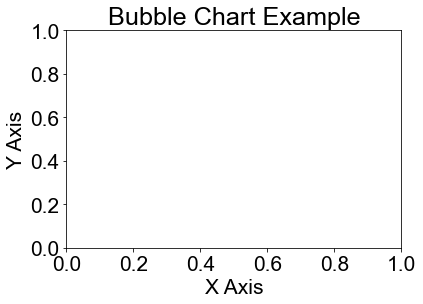

In [112]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Scatter(x=df_13['13_AI _solutions'], 
                                 y=df_13['13_AI_usage'], 
               mode='markers',
            marker=dict(
                size=df_13['count'],
                sizemode='area',
                sizeref=2.*max(df_13['count'])/(40.**2),
                sizemin=4)
            )])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Bubble Chart Example')


In [113]:
from plotnine import ggplot, geom_point, aes, theme_minimal, scale_size, element_text

# Sample input data in a DataFrame
data = {'X': [1, 2, 3, 4, 5] * 5,
        'Y': list(range(1, 6)) * 5,
        'count': [10, 20, 30, 40, 50,
                  60, 70, 80, 90, 100,
                  110, 120, 130, 140, 150,
                  160, 170, 180, 190, 200,
                  210, 220, 230, 240, 250]}
df = pd.DataFrame(data)

# Create a bubble grid chart with Y axis on the right side
(ggplot(df, aes(x='X', y='Y', size='count')) +
 geom_point() +
 scale_size(range=[2, 20]) +  # Adjust bubble size range
 theme_minimal() +
 theme(axis_title_y=element_text(hjust=0.5),  # Center Y axis title
       axis_text_y=element_blank(),             # Remove Y axis labels
       axis_title_x=element_text(hjust=0),     # Left-align X axis title
       axis_text_x=element_text(hjust=0),      # Left-align X axis labels
       axis_ticks_minor_x=element_blank(),     # Remove minor X ticks
       axis_line_y=element_line(color='black'),  # Y axis line color
       axis_line_y_position=0.95)              # Position of Y axis line
)


PlotnineError: 'There no themeable element called: axis_line_y_position'

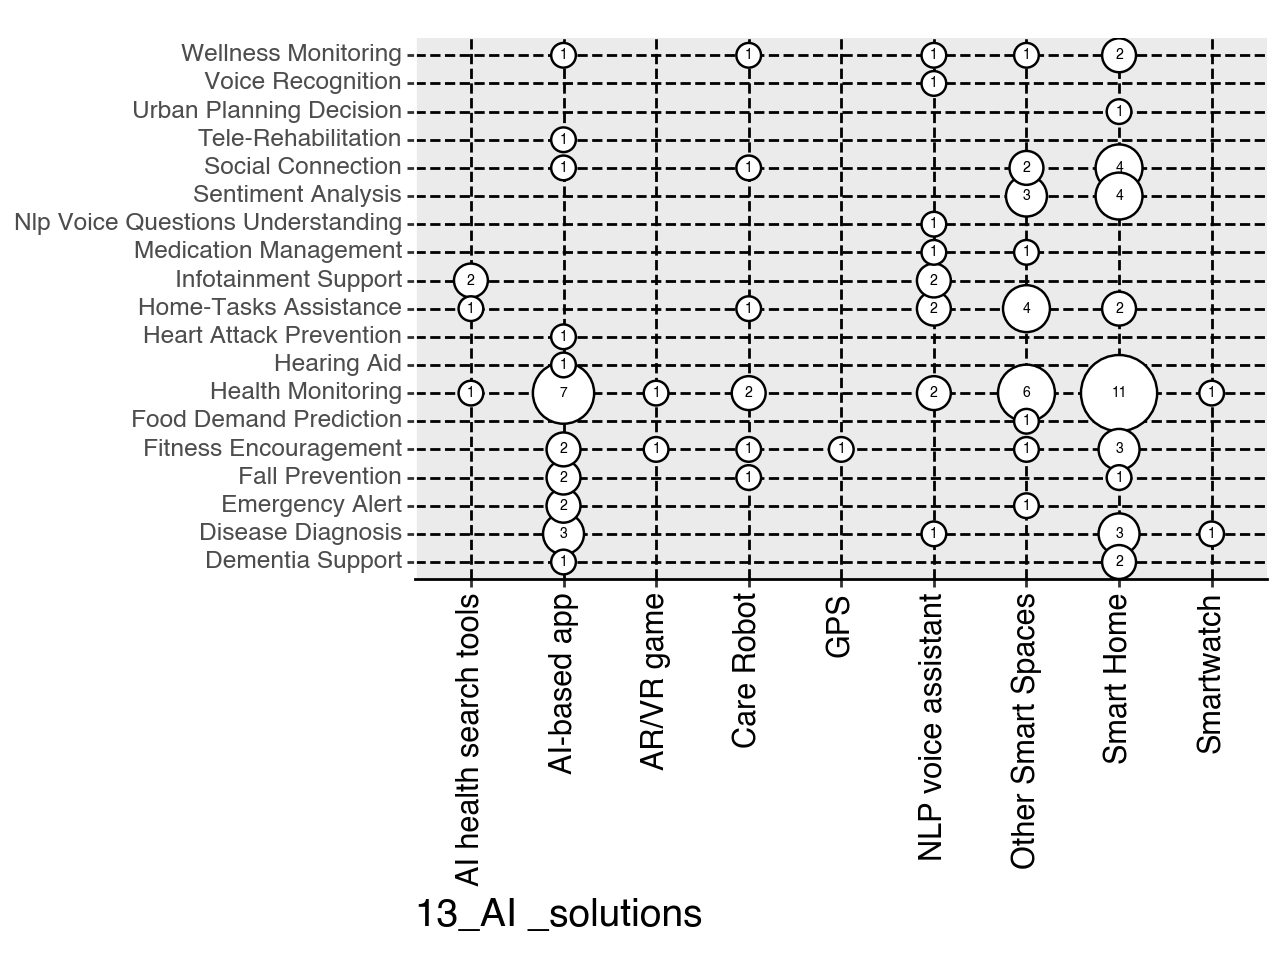

<Figure Size: (640 x 480)>

In [114]:


ggplot(df_13, aes('13_AI _solutions','13_AI_usage')) + \
       geom_point(aes(size='dotsize'),fill='white') + \
       geom_text(aes(label='count'),size=5) + \
       scale_size_identity() + \
       theme(panel_grid_major=element_line(linetype='dashed', color="black"),
                axis_title_x=element_text(size=14, face="bold", hjust=0),
                axis_title_y=element_blank(),
                axis_text_x=element_text(size=11, angle=90, color="black"),
                axis_line_x=element_line(colour="black"),
                axis_line_y=element_line(colour="white"),
                plot_margin=0.01,
                plot_title=element_text(size=15, face="bold", hjust=0.5))

#        theme(panel_grid_major=element_line(linetype='dashed',color='black',alpha =0.3),
#                axis_title_x=element_text(hjust=0),     # Left-align X axis title
#              axis_title_y=element_text(hjust=0), 
#              axis_text_x=element_text(angle=90,hjust=0,vjust=1))

# .save('mygraph.png')
# (ggplot(df_13)
#  + aes(x='13_AI _solutions', y='13_AI_usage')
#  + geom_count(alpha=0.5)

#  + labs(title='Engine Displacement vs. Highway Miles per Gallon', x='Engine Displacement, in Litres', y='Highway Miles per Gallon')
# )

In [115]:
import plotly.graph_objects as go

# List of strings to display
strings = df_13['13_AI_usage'].unique().tolist()
# Create an empty figure
fig_mid = go.Figure()

# Define the position for the annotations
x_pos = 0.1  # X position for the annotations
y_start = 1  # Starting Y position
y_step = -0.1  # Step for each string

# Add annotations for each string
for i, string in enumerate(strings):
    fig_mid.add_annotation(
        x=x_pos,
        y=y_start + i * y_step,
        text=string,
        showarrow=False,
        xanchor="left",
        yanchor="top",
        font=dict(size=12)
    )

# # Set the layout for the figure to remove axis labels and ticks
# fig_mid.update_layout(
#     title_text='AI_usage',
#     xaxis=dict(showticklabels=False),
#     yaxis=dict(showticklabels=False),
#     xaxis_title=None,
#     yaxis_title=None,
#     xaxis_range=[0, 1],
#     yaxis_range=[-0.1 * len(strings), 1],
#     margin=dict(l=0, r=0, t=40, b=0),
# )

fig_mid.show()

In [116]:
df_13

,13_AI _solutions,13_AI_usage,count,dotsize
3,Smart Home,Health Monitoring,11,14.969641
17,AI-based app,Health Monitoring,7,11.941643
7,Other Smart Spaces,Health Monitoring,6,11.055813
22,Other Smart Spaces,Home-Tasks Assistance,4,9.027033
14,Smart Home,Social Connection,4,9.027033
0,Smart Home,Sentiment Analysis,4,9.027033
2,Smart Home,Disease Diagnosis,3,7.817640
12,AI-based app,Disease Diagnosis,3,7.817640
5,Smart Home,Fitness Encouragement,3,7.817640
21,Other Smart Spaces,Sentiment Analysis,3,7.817640


In [117]:
# gridColor = '#7bccc4'  #green style
# bgColor = '#ccebc5'    #green style
gridColor = '#969696'  #grey style
bgColor = '#d9d9d9'    #grey style

In [118]:
#43a2ca, #0868ac

import plotly.express as px 
from plotly.subplots import make_subplots
  
fig_13 = px.scatter(df_13, x='13_AI_usage', y='13_AI _solutions', 
                 size='dotsize', text='count',size_max=28, 
                 hover_data=['count']# Outline color and width
#                     ,  color='color'
                   ) 
fig_13.update_traces(textfont=dict(size=16), marker=dict(color='white', line=dict(color='black', width=1.5),opacity=0.9)) 
fig_13.update_yaxes(showticklabels=False)
strings = df_13['13_AI_usage'].unique().tolist()
x_pos = 0.5  # X position for the annotations (centered)
y_start = 1  # Starting Y position
y_step = -0.2  # Step for each string (spacing between lines)

for i, string in enumerate(strings):
    fig.add_annotation(
        x=x_pos,
        y=y_start + i * y_step,
        text=string,
        showarrow=False,
        xanchor="center",
        yanchor="top",
        font=dict(size=12),
        xref="x2",  # Reference to the x-axis of the middle subplot
        yref="y2"   # Reference to the y-axis of the middle subplot
    )

fig_14 = px.scatter(df_14, x='13_AI_usage', y='14_data_capture', 
                 size='dotsize', text='count',size_max=35,
                 hover_data=['count']) 
fig_14.update_traces(textfont=dict(size=16), marker=dict(color='white', line=dict(color='black', width=1.5),opacity=0.9)) 
fig_14.update_yaxes(showticklabels=False)
# Get the category order from fig_13
category_order = fig_13.layout.yaxis.categoryorder

# Update the y-axis of fig_14 with the same category order
fig_14.update_yaxes(categoryorder=category_order)
for trace in fig_14.data:
    fig_13.add_trace(trace)

# Show the combined figure
# fig_13.show()
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.28, row_heights=[0.45, 0.55])

# Add each figure to a subplot
fig.add_trace(fig_13.data[0], row=1, col=1)
fig.add_trace(fig_14.data[0], row=2, col=1)
fig.update_xaxes(title_text='', row=1, col=1, gridcolor=gridColor,gridwidth=2, griddash="dash")
fig.update_yaxes(title_text='AI Solutions', row=1, col=1, gridcolor=gridColor,gridwidth=2, griddash="dash")
fig.update_xaxes(title_text='', row=2, col=1, tickangle=90, gridcolor=gridColor,gridwidth=2, griddash="dash")
fig.update_yaxes(title_text='Data Capture', row=2, col=1, gridcolor=gridColor,gridwidth=2, griddash="dash")

# Hide the axes for the middle subplot
fig.update_xaxes(showticklabels=False, row=2, col=1)
# fig.update_yaxes(showticklabels=False, row=1, col=2),title_text="Data Capture Vs AI Usage Vs AI Solutions",
fig.update_layout(width=1000, height=1000, showlegend=False, 

                    paper_bgcolor='white',
                    plot_bgcolor=bgColor,
                  font=dict(family="Arial, sans-serif",size=20,color="black")
#                  plot_bgcolor='#f0f9e8',  # Background color of the plotting area
#                     paper_bgcolor='white'
                 )
fig.show()

In [119]:
df_RE4D_2['20'].unique()

array(['User Stories', 'Use Case Modeling', 'Structured English',
       'Affinity Diagraming', 'Personas', 'Activity Diagram',
       'Meta Model', 'Goal Model', 'Ontology Modelling', 'Unclear',
       'User Centered Design', 'Conceptual Model',
       'Entity-Relationship Modeling'], dtype=object)

In [120]:
#43a2ca, #0868ac

import plotly.express as px 
from plotly.subplots import make_subplots
  
fig_13 = px.scatter(df_RE4D_1, x='13_AI _solutions', y='19', 
                 size='dotsize', text='count',size_max=28, 
                 hover_data=['count']# Outline color and width
#                     ,  color='color'
                   ) 
fig_13.update_traces(textfont=dict(size=16), marker=dict(color='white', line=dict(color='black', width=1.5),opacity=0.9)) 
fig_13.update_yaxes(showticklabels=False)
strings = df_RE4D_1['13_AI _solutions'].unique().tolist()
x_pos = 0.5  # X position for the annotations (centered)
y_start = 1  # Starting Y position
y_step = -0.2  # Step for each string (spacing between lines)

for i, string in enumerate(strings):
    fig.add_annotation(
        x=x_pos,
        y=y_start + i * y_step,
        text=string,
        showarrow=False,
        xanchor="center",
        yanchor="top",
        font=dict(size=12),
        xref="x2",  # Reference to the x-axis of the middle subplot
        yref="y2"   # Reference to the y-axis of the middle subplot
    )

fig_14 = px.scatter(df_RE4D_2, x='13_AI _solutions', y='20', 
                 size='dotsize', text='count',size_max=35,
                 hover_data=['count']) 
fig_14.update_traces(textfont=dict(size=16), marker=dict(color='white', line=dict(color='black', width=1.5),opacity=0.9)) 
fig_14.update_yaxes(showticklabels=False)
# Get the category order from fig_13
category_order = fig_13.layout.yaxis.categoryorder

# Update the y-axis of fig_14 with the same category order
fig_14.update_yaxes(categoryorder=category_order)
for trace in fig_14.data:
    fig_13.add_trace(trace)

# Show the combined figure
# fig_13.show()
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.2, row_heights=[0.5, 0.5])

# Add each figure to a subplot
fig.add_trace(fig_13.data[0], row=1, col=1)
fig.add_trace(fig_14.data[0], row=2, col=1)
fig.update_xaxes(title_text='', row=1, col=1, gridcolor=gridColor,gridwidth=2, griddash="dash")
fig.update_yaxes(title_text='Requirements Collecting', row=1, col=1, gridcolor=gridColor,gridwidth=2, griddash="dash")
fig.update_xaxes(title_text='', row=2, col=1, tickangle=90, gridcolor=gridColor,gridwidth=2, griddash="dash")
fig.update_yaxes(title_text='Requirements Modelling', row=2, col=1, gridcolor=gridColor,gridwidth=2, griddash="dash")

# Hide the axes for the middle subplot
fig.update_xaxes(showticklabels=False, row=2, col=1)
# fig.update_yaxes(showticklabels=False, row=1, col=2),title_text="Data Capture Vs AI Usage Vs AI Solutions",
fig.update_layout(width=1000, height=1000, showlegend=False, 

                    paper_bgcolor='white',
                    plot_bgcolor=bgColor,
                  font=dict(family="Arial, sans-serif",size=20,color="black")
#                  plot_bgcolor='#f0f9e8',  # Background color of the plotting area
#                     paper_bgcolor='white'
                 )
fig.show()

In [121]:
import pandas as pd
from itertools import combinations

# Input data
data1 = {
    'Personal Preferences': 'S11, S13, S17, S20, S23, S37, S38, S4, S40, S42, S5, S50, S54, S57, S62, S64, S8, S9, S69, S59, S51, S66',
    'Emotions': 'S1, S12, S13, S17, S38, S4, S41, S5, S62, S64, S7',
    'Fitness Lifestyle': 'S9, S43',
    'Personality': 'S10, S64, S8, S44',
    'life experience': 'S10, S6, S53',
    'Living/family situation or Societal Influences':'S1, S11, S14, S15, S16, S2, S22, S23, S25, S28, S30, S31, S32, S35, S36, S37, S4, S40, S42, S44, S46, S47, S49, S5, S53, S55, S60, S62, S63, S8, S9, S68, S29, S59, S51',
    'Culture/Ethnicity':'S5, S15, S17, S30, S31, S32, S55, S60, S59',
    'Environmental and Location':'S11, S2, S53, S56, S64, S8, S9',
    'Socio-economic status':'S1, S12, S20, S3, S30, S31, S32, S53, S8',
    'Parent status':'S3, S58',
    'loneliness':'S23, S9',
    'Physical and Mental Challenges':'S11, S12, S13, S14, S15, S16, S17, S20, S22, S24, S25, S26, S27, S28, S3, S33, S34, S35, S36, S37, S38, S40, S41, S42, S44, S46, S47, S5, S50, S52, S53, S54, S6, S60, S62, S63, S64, S7, S8, S9, S65, S39, S21, S69, S29, S59, S51, S66',
    'Comfort with technology':'S1, S10, S11, S12, S13, S2, S20, S22, S26, S28, S32, S34, S35, S36, S38, S40, S42, S43, S45, S46, S47, S49, S53, S54, S56, S63, S64, S8, S39, S29',
    'Gender':'S20, S22, S28, S30, S31, S32, S35, S40, S42, S44, S50, S53, S55, S60, S62, S63, S29, S59, S66',
    'Cognitive and Educational level':'S1, S15, S10, S11, S17, S22, S26, S27, S28, S30, S31, S32, S35, S42, S50, S55, S66, S4, S43, S47, S5, S54, S63, S9, S65, S68, S21, S59',
    'Occupation and skill level':'S2, S35, S40, S42, S43, S46, S50, S55, S63, S64',
    'smoking':'S42'
}

data2 = {
    'chronic challenge': 'S36, S42, S18, S42, S44, S13, S7',
    'acute disease': 'S38',
    'long-term care challenges': 'S1, S14, S16, S19, S2, S20,  S21, S23, S25, S26, S31, S33, S35, S39, S46, S40, S41, S47, S48, S5, S56, S57, S59, S61, S62, S63, S9, S68, S64, S69, S67, S66',
    'mental health/emotional challenges':'S17, S19, S22, S28, S37, S4, S43, S52, S54, S58, S65,S51,S41,S3',
    'aging in general':'S1, S10, S11, S12, S15, S17, S24, S27, S30, S32, S29, S34, S45, S49, S50, S53, S55, S6, S60, S64, S8'

}

# Function to convert input data to a dictionary of sets
def convert_to_sets(data):
    data_sets = {}
    for category, subjects in data.items():
        subject_set = set(subjects.split(', '))
        data_sets[category] = subject_set
    return data_sets

# Convert input data to sets
sets1 = convert_to_sets(data1)
sets2 = convert_to_sets(data2)

# Combine the two sets dictionaries
# all_sets = {**sets1, **sets2}

# Find common subjects between each pair of categories
rows = []
for (cat1, subjects1) in sets1.items():
    for (cat2, subjects2) in sets2.items():
        common_subjects = subjects1.intersection(subjects2)
        print(common_subjects)
        if common_subjects:
            rows.append({'Human Aspects': cat1, 'Health Aspects': cat2, 'count': len(common_subjects)})

# Create the resulting DataFrame
result_df = pd.DataFrame(rows)

# Print the resulting DataFrame
print(result_df)


{'S42', 'S13'}
{'S38'}
{'S20', 'S66', 'S5', 'S62', 'S64', 'S23', 'S59', 'S57', 'S40', 'S69', 'S9'}
{'S4', 'S37', 'S54', 'S17'}
{'S11', 'S8', 'S64', 'S50', 'S17'}
{'S7', 'S13'}
{'S38'}
{'S1', 'S62', 'S5', 'S64', 'S41'}
{'S4', 'S17'}
{'S64', 'S1', 'S12', 'S17'}
set()
set()
{'S9'}
{'S43'}
set()
{'S44'}
set()
{'S64'}
set()
{'S8', 'S10', 'S64'}
set()
set()
set()
set()
{'S6', 'S10', 'S53'}
{'S42', 'S44', 'S36'}
set()
{'S35', 'S1', 'S14', 'S16', 'S5', 'S62', 'S68', 'S63', 'S2', 'S25', 'S23', 'S46', 'S47', 'S59', 'S40', 'S9', 'S31'}
{'S22', 'S4', 'S37', 'S28'}
{'S1', 'S11', 'S30', 'S8', 'S53', 'S15', 'S55', 'S29', 'S32', 'S49', 'S60'}
set()
set()
{'S59', 'S31', 'S5'}
{'S17'}
{'S30', 'S15', 'S55', 'S32', 'S17', 'S60'}
set()
set()
{'S2', 'S56', 'S64', 'S9'}
set()
{'S53', 'S8', 'S64', 'S11'}
set()
set()
{'S20', 'S1', 'S31'}
set()
{'S1', 'S12', 'S30', 'S8', 'S53', 'S32'}
set()
set()
set()
{'S58'}
set()
set()
set()
{'S23', 'S9'}
set()
set()
{'S36', 'S44', 'S7', 'S13', 'S42'}
{'S38'}
{'S14', 'S16', 

In [261]:

result_df['dotsize'] = result_df.apply(lambda row: math.sqrt((row['count']) / math.pi) * 8, axis=1)
result_df['Human Aspects']= result_df['Human Aspects'].str.title()
result_df['Health Aspects']= result_df['Health Aspects'].str.title()

In [262]:
  
fig = px.scatter(result_df, x='Health Aspects', y='Human Aspects', 
                 size='dotsize', text='count', size_max=35,
                 hover_data=['count']) 
fig.update_traces(textfont=dict(size=16), marker=dict(color='white', line=dict(color='black', width=1.5),opacity=0.9)) 
fig.update_xaxes(gridcolor=gridColor, gridwidth=2, griddash="dash")
fig.update_yaxes(gridcolor=gridColor, gridwidth=2, griddash="dash")

# fig.update_yaxes(showticklabels=False)
fig.update_layout(width=1000, height=900, font=dict(family="Arial, sans-serif",size=20,color="black"),
                 plot_bgcolor=bgColor,  # Background color of the plotting area
                    paper_bgcolor='white')
fig.show()

In [263]:
import plotly.graph_objects as go

# Create a trace
trace = go.Scatter(
    x=df_13['13_AI _solutions'],
    y=df_13['13_AI_usage'],
    mode='markers',
    marker=dict(size=df_13['dotsize']),
    text=df_13['count'],
    hoverinfo='text'
)

# Create a layout
layout = go.Layout()

# Create a figure and add the trace
fig = go.Figure(data=[trace], layout=layout)

# Update the trace's text font size
fig.update_traces(textfont=dict(size=12))
fig.update_layout(width=500, height=500)
# Show the figure
fig.show()


In [264]:
(ggplot(df_13)
 + aes(x='13_AI _solutions', y='13_AI_usage')
 + geom_count(alpha=0.5, size  = counts)

 + labs(title='Engine Displacement vs. Highway Miles per Gallon', x='Engine Displacement, in Litres', y='Highway Miles per Gallon')
)

NameError: name 'counts' is not defined

In [ ]:
(ggplot(diamonds)
 + aes(x='cut', y='color')
 + geom_count(alpha=0.5)
 + labs(title='Engine Displacement vs. Highway Miles per Gallon', x='Engine Displacement, in Litres', y='Highway Miles per Gallon')
)

In [ ]:


# Scatter plot with bubble size based on 'sizes' column
plt.scatter(df_RQ1['14_data_collection_tool'], df_RQ1['13_AI_usage'], s=df['sizes'])

fig, ax1 = plt.subplots()

# Scatter plot with bubble size based on 'sizes1' for y1
ax1.scatter(df_RQ1['13_AI _solutions'], df_RQ1['13_AI_usage'], s=df['sizes1'], color='b', label='Y1')
ax1.set_xlabel('X1-axis Label', color='b')
ax1.set_ylabel('Y-axis Label')

# Create a second y-axis
ax2 = ax1.twinx()
# Scatter plot with bubble size based on 'sizes2' for y2
ax2.scatter(df_RQ1['14_data_collection_tool'], df_RQ1['13_AI_usage'], s=df['sizes2'], color='r', label='Y2')
ax2.set_xlabel('X2-axis Label', color='r')

# Add a legend
fig.legend(loc='upper left')

plt.title('AI_Method-Usage-DataCollections')
plt.show()


In [124]:
data = {'ID': df_RQ2['Paper ID'], 'Categories': df_RQ2['21'].astype(str).apply(lambda x: re.split(r',(?![^()]*\))', str(x.replace(", ", ","))))}
df = pd.DataFrame(data)


In [125]:

# Extract unique categories
all_categories = list(set(category for categories in df['Categories'] for category in categories))
all_categories.sort()
print(set(all_categories))

{'Technology Acceptance Model (TAM)', 'Use Cases Validation (eg.input/output)', 'External Reviews', 'Requirements Reviews/Inspections', 'Requirements Review', 'cross validation by the documents analysis', 'Requirement Testing Design', 'Balanced Scorecard (BSC) ', 'User Acceptance Testing (UAT)', 'Asked for stakeholder feedback(eg.workshops)', 'System Usability Scale (SUS)', 'Scenario Testing', 'Prototyping and Proof of Concept', 'Co-design', 'Non'}


In [126]:


ppr_ls = []
counts_list = []
for category in all_categories:
    IDs = df[df['Categories'].apply(lambda x: category in x)]['ID'].tolist()    
    counts = len(IDs)
    
    ppr_ls.append(IDs)
    counts_list.append(counts)
    

df = pd.DataFrame({'ID': all_categories,'Papers':ppr_ls,'Occurrences': counts_list})



In [127]:
# Extract unique categories
all_categories = list(set(category for _, categories in data for category in categories))
all_categories.sort()

# Prepare data for plotting
x_labels = [f'Data {i+1}' for i in range(len(data))]
y_values = []

for category in all_categories:
    category_data = [1 if category in categories else 0 for _, categories in data]
    y_values.append(category_data)

# Create a stacked bar chart
fig, ax = plt.subplots()

ax.bar(x_labels, y_values[0], label=f'Category {all_categories[0]}', color='skyblue')

for i in range(1, len(all_categories)):
    ax.bar(x_labels, y_values[i], bottom=np.sum(y_values[:i], axis=0), label=f'Category {all_categories[i]}')

# Adding labels and title
ax.set_xlabel('Data Points')
ax.set_ylabel('Presence of Categories')
ax.set_title('Multi-Category Data with Crossed Categories')
ax.legend()

# Show the plot
plt.show()

ValueError: too many values to unpack (expected 2)

In [128]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
data = [(1, ['A']), (2, ['A', 'B']), (3, ['A', 'C']), (4, ['B'])]

# Extract unique categories
all_categories = list(set(category for _, categories in data for category in categories))
all_categories.sort()

# Prepare data for plotting
x_labels = all_categories
y_values = []

for category in all_categories:
    category_data = [1 if category in categories else 0 for _, categories in data]
    y_values.append(category_data)

# Calculate percentages
percentages = np.array(y_values) / len(data) * 100

# Convert percentages to strings with one decimal place
percentage_strings = ["{:.1f}%".format(value) for value in percentages]

# Create a bar chart with percentages
fig, ax = plt.subplots()

bar_width = 0.8
bar_positions = np.arange(len(all_categories))

for i, category in enumerate(all_categories):
    ax.bar(
        bar_positions, 
        percentages[i], 
        bar_width, 
        label=f'{category} - {percentage_strings[i]}',
    )
# Adding labels and title
ax.set_xlabel('Categories')
ax.set_ylabel('Percentage of Data')
ax.set_title('Percentage of Data in Each Category')
ax.set_xticks(bar_positions)
ax.set_xticklabels(all_categories)
ax.legend()

# Show the plot
plt.show()


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [8]:
df.stb.freq(['Paper ID'], value='Sale (Dollars)', style=True, cum_cols=False)


NameError: name 'df' is not defined

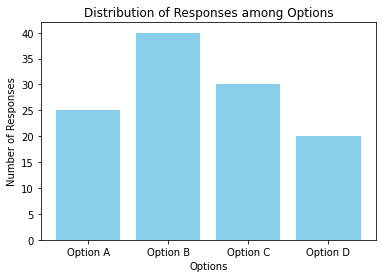

In [41]:
import matplotlib.pyplot as plt

# Example dataset (replace this with your data)
options = ['Option A', 'Option B', 'Option C', 'Option D']
responses = [25, 40, 30, 20]

# Create a bar chart
plt.bar(options, responses, color='skyblue')

# Adding labels and title
plt.xlabel('Options')
plt.ylabel('Number of Responses')
plt.title('Distribution of Responses among Options')

# Show the plot
plt.show()


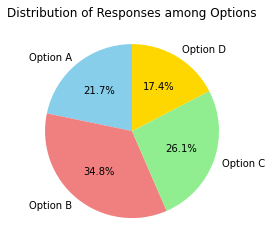

In [42]:
import matplotlib.pyplot as plt

# Example dataset (replace this with your data)
options = ['Option A', 'Option B', 'Option C', 'Option D']
responses = [25, 40, 30, 20]

# Create a pie chart
plt.pie(responses, labels=options, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen', 'gold'])

# Adding title
plt.title('Distribution of Responses among Options')

# Show the plot
plt.show()


In [334]:
def count_number(ls:str):
    items_list = [f"'{item.strip()}'" for item in ls.split(',')]
    print(set(items_list))
    return len(set(items_list))

In [134]:
my_list = 'S1, S17, S18, S23, S35, S36, S38, S42, S46, S47, S50, S52, S53, S54, S55, S56, S64, S65, S21, S29,S2, S22, S27, S40, S5, S6, S61, S62, S67, S51, S66,S11, S24, S28, S34, S35, S43, S44, S50, S60, S8, S39, S69, S59'

print(count_number(my_list)) 

NameError: name 'count_number' is not defined

In [345]:
print(count_number(my_list)/69) 

{"'S27'", "'S2'", "'S8'", "'S51'", "'S11'", "'S24'", "'S17'", "'S44'", "'S34'", "'S5'", "'S65'", "'S67'", "'S23'", "'S6'", "'S1'", "'S38'", "'S55'", "'S28'", "'S50'", "'S22'", "'S54'", "'S56'", "'S18'", "'S52'", "'S53'", "'S36'", "'S39'", "'S46'", "'S43'", "'S66'", "'S62'", "'S69'", "'S64'", "'S42'", "'S21'", "'S59'", "'S35'", "'S60'", "'S40'", "'S47'", "'S29'", "'S61'"}
0.6086956521739131


In [343]:
1/69

0.014492753623188406

In [30]:
def order_string(ls:str):
    items_list = [f"{item.strip()}" for item in ls.split(',')]
    clean_list = [s.replace("\\ ", "") for s in items_list]
    print(clean_list)
    sorted_strings = sorted(clean_list, key=lambda x: int(x[1:]))
    output = ", ".join(sorted_strings)
    return output

In [133]:

my_list = 'S2, S7, S8, S11, S41, S62, S6'

print(order_string(my_list)) 

['S2', 'S7', 'S8', 'S11', 'S41', 'S62', 'S6']
S2, S6, S7, S8, S11, S41, S62


In [29]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Extract the sets from the data
healthcare_providers = data['healthcare providers']
families = data['families']
clinicians = data['clinicians']

# Function to create a Venn diagram with annotations
def create_venn3_with_annotations():
    plt.figure(figsize=(10, 10))
    venn = venn3([healthcare_providers, families, clinicians], ('Healthcare Providers', 'Families', 'Clinicians'))
    
    # Define the subsets
    subsets = {
        '100': healthcare_providers - families - clinicians,
        '010': families - healthcare_providers - clinicians,
        '001': clinicians - healthcare_providers - families,
        '110': healthcare_providers & families - clinicians,
        '101': healthcare_providers & clinicians - families,
        '011': families & clinicians - healthcare_providers,
        '111': healthcare_providers & families & clinicians
    }
    
    # Add text annotations for each subset
    for subset_id, subset_items in subsets.items():
        if venn.get_label_by_id(subset_id) is not None:
            items = ', '.join(subset_items)
            venn.get_label_by_id(subset_id).set_text(f'{venn.get_label_by_id(subset_id).get_text()}\n({items})')
    
    plt.title("3-Set Venn Diagram with Annotations")
    plt.show()

# Call the function to create and show the Venn diagram
create_venn3_with_annotations()


KeyboardInterrupt: 

In [79]:
from itertools import combinations
from functools import reduce
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

def compute_subsets(*sets):
    # Calculate all possible intersections and differences
    all_elements = set().union(*sets)
    subsets = {}

    for r in range(len(sets) + 1):
        for combo in combinations(range(len(sets)), r):
            combo_set = reduce(lambda x, y: x & y, (sets[i] for i in combo), all_elements)
            key = ''.join(['1' if i in combo else '0' for i in range(len(sets))])
            subsets[key] = combo_set

    return subsets

def plot_venn(subsets, labels):
    num_sets = len(labels)
    if num_sets == 2:
        venn = venn2(subsets=(len(subsets['10']), len(subsets['01']), len(subsets['11'])),
                     set_labels=labels)
        venn.get_label_by_id('10').set_text('\n'.join(subsets['10']))
        venn.get_label_by_id('01').set_text('\n'.join(subsets['01']))
        venn.get_label_by_id('11').set_text('\n'.join(subsets['11']))
        plt.title("Venn Diagram of Categories")
        plt.show()
    elif num_sets == 3:
        venn = venn3(subsets=(len(subsets['100']), len(subsets['010']), len(subsets['110']),
                              len(subsets['001']), len(subsets['101']), len(subsets['011']), len(subsets['111'])),
                     set_labels=labels)
        venn.get_label_by_id('100').set_text('\n'.join(subsets['100']))
        venn.get_label_by_id('010').set_text('\n'.join(subsets['010']))
        venn.get_label_by_id('110').set_text('\n'.join(subsets['110']))
        venn.get_label_by_id('001').set_text('\n'.join(subsets['001']))
        venn.get_label_by_id('101').set_text('\n'.join(subsets['101']))
        venn.get_label_by_id('011').set_text('\n'.join(subsets['011']))
        venn.get_label_by_id('111').set_text('\n'.join(subsets['111']))
        plt.title("Venn Diagram of Categories")
        plt.show()
    else:
        print("Venn diagram plotting is only supported for 2 or 3 sets.")
        return




In [91]:
import pandas as pd
from upsetplot import UpSet
import matplotlib.pyplot as plt

# Define the data
data = {
    'healthcare providers': {'S10', 'S11', 'S13', 'S15', 'S2', 'S25', 'S28', 'S3', 'S34', 'S36', 'S4', 'S41', 'S42', 'S45', 'S46', 'S47', 'S48', 'S52', 'S55', 'S56', 'S58', 'S6', 'S60', 'S61', 'S62', 'S63', 'S9', 'S67', 'S51', 'S66', 'S62', 'S7'},
    'families': {'S11', 'S2', 'S25', 'S3', 'S42', 'S48', 'S5', 'S62', 'S7', 'S69', 'S62'},
    'clinicians & nurses': {'S27', 'S38', 'S52', 'S7', 'S37', 'S67','S5'},
    'nurses': {'S5', 'S55', 'S62', 'S67'},
    'volunteers': {'S37', 'S5', 'S58'},
    'computer scientists': {'S38', 'S52', 'S8', 'S37', 'S57', 'S61'},
    'Education experts': {'S2', 'S52'},
    'physicians': {'S55'},
    'pharmacists': {'S38'},
    'geriatricians': {'S5'},
    'dementia experts': {'S8'},
    'Care managers': {'S47'},
    'work colleagues': {'S2'}
}


# Convert the data into sets
sets = [data[key] for key in data.keys()]
labels = list(data.keys())

# Call the function to compute subsets
subsets = compute_subsets(*sets)
for key in subsets:
    subsets[key] = {', '.join(subsets[key])}

# Print the subsets
for key, value in subsets.items():
    
    if value!={''}:
        print(f"{key}: {value}")

# Plot the Venn diagram if there are 2 or 3 sets
plot_venn(subsets, labels)




0000000000000: {'S67, S7, S28, S48, S27, S47, S58, S36, S13, S6, S52, S56, S8, S55, S25, S3, S9, S51, S38, S5, S41, S10, S57, S62, S4, S60, S45, S37, S63, S61, S2, S34, S46, S66, S69, S42, S15, S11'}
1000000000000: {'S67, S7, S28, S48, S47, S58, S36, S13, S6, S52, S56, S55, S25, S3, S9, S51, S41, S10, S62, S4, S60, S45, S63, S61, S2, S34, S46, S66, S42, S15, S11'}
0100000000000: {'S7, S48, S2, S25, S3, S62, S69, S42, S5, S11'}
0010000000000: {'S67, S37, S7, S52, S27, S38, S5'}
0001000000000: {'S5, S67, S62, S55'}
0000100000000: {'S5, S58, S37'}
0000010000000: {'S37, S57, S52, S8, S61, S38'}
0000001000000: {'S52, S2'}
0000000100000: {'S55'}
0000000010000: {'S38'}
0000000001000: {'S5'}
0000000000100: {'S8'}
0000000000010: {'S47'}
0000000000001: {'S2'}
1100000000000: {'S7, S48, S2, S25, S3, S62, S42, S11'}
1010000000000: {'S52, S67, S7'}
1001000000000: {'S67, S62, S55'}
1000100000000: {'S58'}
1000010000000: {'S52, S61'}
1000001000000: {'S52, S2'}
1000000100000: {'S55'}
1000000000010: {'S4